
#  **TELECOM X — ANÁLISIS DE EVASIÓN DE CLIENTES**




# Paso 1: Extracción de Datos desde la API
# ============================================================

In [ ]:
#Importando las librerias necesarias
import requests
import pandas as pd
import json


In [ ]:
#1. Cargamos los datos directamente desde la API(Github)

URL_API = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(URL_API)

#Excepción automática si hay una estado alterado
try:
  response.raise_for_status()
  print(f"Conexión exitosa-Código de estado: {response.status_code}")

except request.exceptions.Timeout:
  print("Tiempo de espera agotado")
  sys.exit(1)

except request.exceptions.ConnectionError:
  oprint("Error de conexión")
  sys.exit(1)

except request.exceptions.RequestException as e:
  print(f"Error de solicitud: {e}")
  sys.exit(1)

except request.exceptions.HTTPError as e:
  print(f"Error HTTP: {e}")
  sys.exit(1)
#Verificamos que hubo una solicitud exitosa


Conexión exitosa-Código de estado: 200


In [ ]:
#1. Parsear el JSON
try:
  data= response.json()
  print("✅ JSON parseado correctamente")

except json.JSONDecodeError as e:
    print(f"ERROR: La respuesta no tiene formato JSON válido — {e}")
    print(f"   Respuesta recibida (primeros 200 chars): {response.text[:200]}")
    sys.exit(1)

except Exception as e:
    print(f"ERROR inesperado al parsear JSON: {e}")
    sys.exit(1)

✅ JSON parseado correctamente


In [ ]:
#3. Exploración inical de JSON

try:
  print(f"\n Tiopo de dato recibido: {type(data)}")

  if isinstance(data, list):
    if len(data) == 0:
      raise ValueError("El JSON está vacío- no contiene registros")
    print(f"Número de registros: {len(data)}")
    print(f"\n Ejemplo del primer registro:")
    print(json.dumps(data[0], indent=4, ensure_ascii=False))

  elif isinstance(data, dict):
    if not data:
      raise ValueError("El JSON es un diccionario vacío")
    print(f"Claves principales del JSON: {list(data.keys())}")

  else:
    raise TypeError(f"Tipo de dato no soportado: {type(data)}")

except ValueError as e:
  print(f"ERROR de datos: {e}")
  sys.exit(1)
except Exception as e:
  print(f"ERROR inesperado explorando el JSON: {e}")
  sys.exit(1)
except TypeError as e:
  print(f"ERROR de tipo: {e}")
  sys.exit(1)




 Tiopo de dato recibido: <class 'list'>
Número de registros: 7267

 Ejemplo del primer registro:
{
    "customerID": "0002-ORFBO",
    "Churn": "No",
    "customer": {
        "gender": "Female",
        "SeniorCitizen": 0,
        "Partner": "Yes",
        "Dependents": "Yes",
        "tenure": 9
    },
    "phone": {
        "PhoneService": "Yes",
        "MultipleLines": "No"
    },
    "internet": {
        "InternetService": "DSL",
        "OnlineSecurity": "No",
        "OnlineBackup": "Yes",
        "DeviceProtection": "No",
        "TechSupport": "Yes",
        "StreamingTV": "Yes",
        "StreamingMovies": "No"
    },
    "account": {
        "Contract": "One year",
        "PaperlessBilling": "Yes",
        "PaymentMethod": "Mailed check",
        "Charges": {
            "Monthly": 65.6,
            "Total": "593.3"
        }
    }
}


In [ ]:
#4. Convertir a DataFrame de Pandas

df= None

try:

  df= pd.json_normalize(data)

  #validamos que el DF no esté vacío
  if df.empty:
    raise ValueError("El DataFrame está vacío")

  #validamos que tenga un minimo razonable de columnas
  if df.shape[1] < 2:
    raise ValueError(f"El dataFrame tiene {df.shape[1]} columnas. Se requieren al menos 2")
  print(f"\n DataFrame creado exitosamente")
  print(f"Dimensiones del DataFrame: {df.shape} filas x {df.shape[1]} columnas")

except ValueError as e:
  print(f"ERROR de validación en DtaFrame: {e}")
  sys.exit(1)

except Exception as e:
  print(f"ERROR inesperado creando el DataFrame: {e}")
  sys.exit(1)


 DataFrame creado exitosamente
Dimensiones del DataFrame: (7267, 21) filas x 21 columnas


In [ ]:
#5. Vista previa de los datos
try:
  print(f"\n Primeras 5 filas del DataFrame:")
  display(df.head())

  print(f"\n Resumen de columnas y tipos de datos")
  print(df.dtypes)

except NameError:
  print("\n Primeras 5 filas del DataFrame:")
  print(df.head())

except Exception as e:
  print(f"ERROR al mostrar los DataFrame: {e}")
  sys.exit(1)



 Primeras 5 filas del DataFrame:


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4



 Resumen de columnas y tipos de datos
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total         object
dtype: object



# Paso 2: Comprobación de Incoherencias en los Datos
# ============================================================

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
#Definimos uina función que n os ayude a separar de forma visual las secciones
def seccion(titulo):
  print("\n" + "="*60)
  print(f"Sección: {titulo}")
  print("="*60)


### 2.1 🔍 Información general del DataFrame
### ============================================================

In [ ]:
seccion("2.1 --Información general del DataFrame")


try:
    print(f"📐 Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
    print(f"\nTipos de datos por columna:")
    print(df.dtypes.to_string())
    print(f"\nResumen estadístico general:")
    display(df.describe(include='all'))

except AttributeError as e:
    print(f"ERROR: El DataFrame no existe o no es válido — {e}")
except Exception as e:
    print(f"ERROR inesperado en información general: {e}")


Sección: 2.1 --Información general del DataFrame
📐 Dimensiones: 7267 filas x 21 columnas

Tipos de datos por columna:
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total         object

Resumen estadístico general:


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
count,7267,7267,7267,7267.000000,7267,7267,7267.000000,7267,7267,7267,...,7267,7267,7267,7267,7267,7267,7267,7267,7267.000000,7267
unique,7267,3,2,NaN,2,2,NaN,2,3,3,...,3,3,3,3,3,3,2,4,NaN,6531
top,9995-HOTOH,No,Male,NaN,No,No,NaN,Yes,No,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2
freq,1,5174,3675,NaN,3749,5086,NaN,6560,3495,3198,...,3182,3195,3582,2896,2870,4005,4311,2445,NaN,11
mean,NaN,NaN,NaN,0.162653,NaN,NaN,32.346498,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.720098,NaN
std,NaN,NaN,NaN,0.369074,NaN,NaN,24.571773,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.129572,NaN
min,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN
25%,NaN,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.425000,NaN
50%,NaN,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.300000,NaN
75%,NaN,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.875000,NaN



### 2.2 Vlores Ausentes (NaN / None / vacíos)
### ============================================================

In [ ]:
seccion("2.2 — VALORES AUSENTES")

# ============================================================
# TELECOM X — VERIFICACIÓN PROFUNDA DE VALORES NULOS/VACÍOS
# ============================================================

import pandas as pd
import numpy as np

seccion("🔬 VERIFICACIÓN PROFUNDA — NULOS DISFRAZADOS")

# ============================================================
# Todos los "disfraces" que puede tener un valor nulo en JSON
# ============================================================

VALORES_NULOS_DISFRAZADOS = [
    'none', 'null', 'nan', 'na', 'n/a',    # Representaciones textuales
    '', ' ', '  ',                           # Vacíos y espacios
    '-', '--', '---',                        # Guiones como placeholder
    'undefined', 'missing', 'unknown',       # Palabras comunes en datasets
    'nil', 'void', '#n/a', '#null!',         # Otros formatos
]

try:
    reporte_profundo = {}

    for col in df.columns:
        try:
            # ── 1. Nulos reales de Python/Pandas ──────────────────
            nulos_reales = df[col].isnull().sum()

            # ── 2. Nulos disfrazados como string ──────────────────
            nulos_disfrazados = df[col].dropna().apply(
                lambda x: str(x).strip().lower() in VALORES_NULOS_DISFRAZADOS
            ).sum()

            # ── 3. Strings con solo espacios en blanco ────────────
            solo_espacios = df[col].dropna().apply(
                lambda x: isinstance(x, str) and x.strip() == '' and x != ''
            ).sum()

            total_problemas = nulos_reales + nulos_disfrazados + solo_espacios

            if total_problemas > 0:
                reporte_profundo[col] = {
                    "🔴 Nulos reales (NaN/None)"    : nulos_reales,
                    "🟡 Nulos disfrazados (string)" : nulos_disfrazados,
                    "🟠 Solo espacios en blanco"    : solo_espacios,
                    "📊 TOTAL PROBLEMAS"            : total_problemas,
                    "📈 % del total"                : round(total_problemas / len(df) * 100, 2)
                }

        except Exception as e_col:
            print(f"⚠️  No se pudo analizar la columna '{col}': {e_col}")

    # ── Mostrar resultados ─────────────────────────────────────────
    if not reporte_profundo:
        print("✅ Verificación profunda completada — No se encontraron valores nulos de ningún tipo.")
    else:
        print(f"⚠️  Se encontraron problemas REALES en {len(reporte_profundo)} columna(s):\n")
        display(
            pd.DataFrame(reporte_profundo)
            .T
            .sort_values("📊 TOTAL PROBLEMAS", ascending=False)
        )

except Exception as e:
    print(f"❌ ERROR inesperado en verificación profunda: {e}")


# ============================================================
# 🧪 VERIFICACIÓN EXTRA — Valores únicos sospechosos
# ============================================================

seccion("🧪 VALORES ÚNICOS SOSPECHOSOS POR COLUMNA")

try:
    encontrados = False

    for col in df.columns:
        try:
            # Buscar en cada columna si algún valor único
            # coincide con nuestros "disfraces"
            unicos_sospechosos = [
                v for v in df[col].dropna().unique()
                if str(v).strip().lower() in VALORES_NULOS_DISFRAZADOS
            ]

            if unicos_sospechosos:
                encontrados = True
                conteo = df[col].apply(
                    lambda x: str(x).strip().lower() in VALORES_NULOS_DISFRAZADOS
                ).sum()
                print(f"⚠️  Columna '{col}': {conteo} ocurrencia(s) de → {unicos_sospechosos}")

        except Exception as e_col:
            print(f"⚠️  No se pudo revisar la columna '{col}': {e_col}")

    if not encontrados:
        print("✅ No se encontraron valores sospechosos en ninguna columna.")

except Exception as e:
    print(f"❌ ERROR inesperado en valores sospechosos: {e}")


# ============================================================
# 📊 CONTEO GLOBAL CONSOLIDADO
# ============================================================

seccion("📊 CONTEO GLOBAL CONSOLIDADO")

try:
    nulos_reales_total = df.isnull().sum().sum()

    nulos_disfrazados_total = df.apply(
        lambda col: col.dropna().apply(
            lambda x: str(x).strip().lower() in VALORES_NULOS_DISFRAZADOS
        ).sum()
    ).sum()

    print(f"  🔴 Nulos reales (NaN/None/NaT)   : {nulos_reales_total}")
    print(f"  🟡 Nulos disfrazados (strings)    : {nulos_disfrazados_total}")
    print(f"  ─────────────────────────────────────")
    print(f"  📊 TOTAL GENERAL DE NULOS         : {nulos_reales_total + nulos_disfrazados_total}")

    if nulos_reales_total + nulos_disfrazados_total == 0:
        print("\n  ✅ Los datos están completamente limpios de valores nulos.")
    else:
        print("\n  ⚠️  Hay valores nulos que deben tratarse antes de continuar.")

except Exception as e:
    print(f"❌ ERROR en conteo global: {e}")


Sección: 2.2 — VALORES AUSENTES

Sección: 🔬 VERIFICACIÓN PROFUNDA — NULOS DISFRAZADOS
⚠️  Se encontraron problemas REALES en 2 columna(s):



,🔴 Nulos reales (NaN/None),🟡 Nulos disfrazados (string),🟠 Solo espacios en blanco,📊 TOTAL PROBLEMAS,📈 % del total
Churn,0.0,224.0,0.0,224.0,3.08
account.Charges.Total,0.0,11.0,11.0,22.0,0.30



Sección: 🧪 VALORES ÚNICOS SOSPECHOSOS POR COLUMNA
⚠️  Columna 'Churn': 224 ocurrencia(s) de → ['']
⚠️  Columna 'account.Charges.Total': 11 ocurrencia(s) de → [' ']

Sección: 📊 CONTEO GLOBAL CONSOLIDADO
  🔴 Nulos reales (NaN/None/NaT)   : 0
  🟡 Nulos disfrazados (strings)    : 235
  ─────────────────────────────────────
  📊 TOTAL GENERAL DE NULOS         : 235

  ⚠️  Hay valores nulos que deben tratarse antes de continuar.



### 2.3 Registros duplicados
#### ============================================================

In [ ]:
seccion("2.3 — REGISTROS DUPLICADOS")
try:
    duplicados_disfrazados = {}

    # ── 1. Duplicados exactos  ─────────────────────
    try:
        total_exactos = df.duplicated().sum()
        duplicados_disfrazados["🔴 Filas exactamente iguales"] = total_exactos
    except Exception as e:
        print(f"⚠️  Error calculando duplicados exactos: {e}")

    # ── 2. Duplicados por columna ID ignorando mayúsculas ─────
    try:
        posibles_ids = [col for col in df.columns if 'id' in col.lower() or 'customer' in col.lower()]
        for col_id in posibles_ids:
            dup_case_insensitive = df[col_id].dropna().apply(
                lambda x: str(x).strip().lower()
            ).duplicated().sum()
            if dup_case_insensitive > 0:
                duplicados_disfrazados[f"🟡 Duplicados en '{col_id}' (ignorando mayúsculas)"] = dup_case_insensitive
    except Exception as e:
        print(f"⚠️  Error en duplicados por ID: {e}")

    # ── 3. Duplicados ignorando espacios en todas las columnas texto ──
    try:
        cols_texto = df.select_dtypes(include='object').columns.tolist()
        df_normalizado = df.copy()
        for col in cols_texto:
            df_normalizado[col] = df_normalizado[col].dropna().apply(
                lambda x: str(x).strip().lower()
            )
        dup_normalizados = df_normalizado.duplicated().sum()
        if dup_normalizados > total_exactos:
            duplicados_disfrazados["🟠 Filas duplicadas al normalizar texto"] = dup_normalizados - total_exactos
    except Exception as e:
        print(f"⚠️  Error en duplicados normalizados: {e}")

    # ── Mostrar resultados ─────────────────────────────────────
    encontrados = {k: v for k, v in duplicados_disfrazados.items() if v > 0}
    if not encontrados:
        print("✅ No se encontraron duplicados de ningún tipo.")
    else:
        print(f"⚠️  Duplicados detectados:\n")
        for tipo, cantidad in encontrados.items():
            print(f"  {tipo}: {cantidad}")

except Exception as e:
    print(f"❌ ERROR inesperado en duplicados disfrazados: {e}")




Sección: 2.3 — REGISTROS DUPLICADOS
⚠️  Duplicados detectados:

  🟡 Duplicados en 'customer.gender' (ignorando mayúsculas): 7265
  🟡 Duplicados en 'customer.SeniorCitizen' (ignorando mayúsculas): 7265
  🟡 Duplicados en 'customer.Partner' (ignorando mayúsculas): 7265
  🟡 Duplicados en 'customer.Dependents' (ignorando mayúsculas): 7265
  🟡 Duplicados en 'customer.tenure' (ignorando mayúsculas): 7194



### 2.4 🔤 Errores de formato y Espacios en Blanco
### ============================================================

In [ ]:
seccion("2.4 — ERRORES DE FORMATO Y ESPACIOS EN BLANCO")

try:
    # ── 1. Números almacenados como strings ───────────────────
    print("🔍 1. Números almacenados como texto:")
    try:
        cols_texto = df.select_dtypes(include='object').columns.tolist()
        numericos_como_string = {}

        for col in cols_texto:
            try:
                convertidos = pd.to_numeric(
                    df[col].dropna().apply(lambda x: str(x).strip().replace(',', '.')),
                    errors='coerce'
                )
                pct_convertibles = convertidos.notna().mean() * 100
                if pct_convertibles > 80:  # Más del 80% son numéricos
                    numericos_como_string[col] = f"{pct_convertibles:.1f}% convertible a número"
            except Exception as e_col:
                print(f"  ⚠️  No se pudo analizar '{col}': {e_col}")

        if not numericos_como_string:
            print("  ✅ No se detectaron columnas numéricas almacenadas como texto.")
        else:
            print(f"  ⚠️  Columnas sospechosas ({len(numericos_como_string)}):")
            for col, detalle in numericos_como_string.items():
                print(f"    → '{col}': {detalle}")
    except Exception as e:
        print(f"  ❌ Error: {e}")

    # ── 2. Booleanos disfrazados ──────────────────────────────
    print("\n🔍 2. Booleanos disfrazados como texto:")
    try:
        VALORES_BOOLEANOS = {
            'si', 'no', 'yes', 'no', 'true', 'false',
            '1', '0', 'verdadero', 'falso',
            'y', 'n', 'on', 'off'
        }

        booleanos_disfrazados = {}
        for col in cols_texto:
            try:
                unicos = set(df[col].dropna().apply(
                    lambda x: str(x).strip().lower()
                ).unique())
                if unicos.issubset(VALORES_BOOLEANOS) and len(unicos) <= 4:
                    conteo = df[col].value_counts().to_dict()
                    booleanos_disfrazados[col] = conteo
            except Exception as e_col:
                print(f"  ⚠️  No se pudo analizar '{col}': {e_col}")

        if not booleanos_disfrazados:
            print("  ✅ No se detectaron booleanos disfrazados.")
        else:
            print(f"  ⚠️  Columnas con posibles booleanos ({len(booleanos_disfrazados)}):")
            for col, conteo in booleanos_disfrazados.items():
                print(f"    → '{col}': {conteo}")
    except Exception as e:
        print(f"  ❌ Error: {e}")

    # ── 3. Símbolos de moneda o caracteres especiales ─────────
    print("\n🔍 3. Símbolos de moneda o caracteres especiales en numéricos:")
    try:
        SIMBOLOS_MONEDA = ['$', '€', '£', '¥', ',', '%', ' ']
        simbolos_detectados = {}

        for col in cols_texto:
            try:
                muestra = df[col].dropna().astype(str)
                for simbolo in SIMBOLOS_MONEDA:
                    tiene_simbolo = muestra.str.contains(
                        re.escape(simbolo), regex=True
                    ).sum()
                    if tiene_simbolo > 0:
                        if col not in simbolos_detectados:
                            simbolos_detectados[col] = []
                        simbolos_detectados[col].append(
                            f"'{simbolo}' en {tiene_simbolo} filas"
                        )
            except Exception as e_col:
                print(f"  ⚠️  No se pudo analizar '{col}': {e_col}")

        if not simbolos_detectados:
            print("  ✅ No se detectaron símbolos especiales.")
        else:
            for col, simbolos in simbolos_detectados.items():
                print(f"  ⚠️  '{col}': {', '.join(simbolos)}")
    except Exception as e:
        print(f"  ❌ Error: {e}")

    # ── 4. Fechas con formato inconsistente ───────────────────
    print("\n🔍 4. Columnas de fecha con formato inconsistente:")
    try:
        import re
        PATRONES_FECHA = [
            r'\d{4}-\d{2}-\d{2}',           # YYYY-MM-DD
            r'\d{2}/\d{2}/\d{4}',           # DD/MM/YYYY
            r'\d{2}-\d{2}-\d{4}',           # DD-MM-YYYY
            r'\d{2}\.\d{2}\.\d{4}',         # DD.MM.YYYY
        ]

        cols_fecha_sospechosas = {}
        for col in cols_texto:
            try:
                muestra = df[col].dropna().astype(str).head(100)
                formatos_encontrados = set()
                for patron in PATRONES_FECHA:
                    coincidencias = muestra.str.match(patron).sum()
                    if coincidencias > 0:
                        formatos_encontrados.add(patron)
                if len(formatos_encontrados) > 1:
                    cols_fecha_sospechosas[col] = formatos_encontrados
            except Exception as e_col:
                print(f"  ⚠️  No se pudo analizar '{col}': {e_col}")

        if not cols_fecha_sospechosas:
            print("  ✅ No se detectaron inconsistencias de formato en fechas.")
        else:
            for col, formatos in cols_fecha_sospechosas.items():
                print(f"  ⚠️  '{col}': múltiples formatos detectados → {formatos}")
    except Exception as e:
        print(f"  ❌ Error: {e}")

except Exception as e:
    print(f"❌ ERROR inesperado en formato disfrazado: {e}")




Sección: 2.4 — ERRORES DE FORMATO Y ESPACIOS EN BLANCO
🔍 1. Números almacenados como texto:
  ⚠️  Columnas sospechosas (1):
    → 'account.Charges.Total': 99.8% convertible a número

🔍 2. Booleanos disfrazados como texto:
  ⚠️  Columnas con posibles booleanos (4):
    → 'customer.Partner': {'No': 3749, 'Yes': 3518}
    → 'customer.Dependents': {'No': 5086, 'Yes': 2181}
    → 'phone.PhoneService': {'Yes': 6560, 'No': 707}
    → 'account.PaperlessBilling': {'Yes': 4311, 'No': 2956}

🔍 3. Símbolos de moneda o caracteres especiales en numéricos:
  ⚠️  'phone.MultipleLines': ' ' en 707 filas
  ⚠️  'internet.InternetService': ' ' en 3198 filas
  ⚠️  'internet.OnlineSecurity': ' ' en 1581 filas
  ⚠️  'internet.OnlineBackup': ' ' en 1581 filas
  ⚠️  'internet.DeviceProtection': ' ' en 1581 filas
  ⚠️  'internet.TechSupport': ' ' en 1581 filas
  ⚠️  'internet.StreamingTV': ' ' en 1581 filas
  ⚠️  'internet.StreamingMovies': ' ' en 1581 filas
  ⚠️  'account.Contract': ' ' en 3262 filas
  ⚠️  'a

### 2.5 🏷️ Inconsistencias en variables categóricas
### ============================================================

In [ ]:
seccion("2.5 — INCONSISTENCIAS EN VARIABLES CATEGÓRICAS")

try:
    from difflib import SequenceMatcher
    cols_texto_list = df.select_dtypes(include='object').columns.tolist()

    # ── Umbrales de rendimiento ────────────────────────────────
    MAX_UNICOS_PARA_TYPOS      = 30   # Solo buscar typos si hay pocos valores únicos
    MAX_UNICOS_PARA_ANALISIS   = 100  # Saltar columnas de muy alta cardinalidad
    MAX_COMPARACIONES_TYPOS    = 200  # Límite de pares a comparar

    PARES_IDIOMA = [
        ('yes','si'),('yes','sí'),('male','masculino'),
        ('female','femenino'),('true','verdadero'),('false','falso')
    ]

    for col in cols_texto_list:
        try:
            valores_unicos = df[col].dropna().unique()
            n_unicos       = len(valores_unicos)

            # ── Saltar columnas de altísima cardinalidad ───────
            if n_unicos > MAX_UNICOS_PARA_ANALISIS:
                print(f"  ⏭️  '{col}' omitida — alta cardinalidad ({n_unicos} únicos)")
                continue

            normalizados = [str(v).strip().lower() for v in valores_unicos]
            problemas_cat = {}

            # ── 1. Capitalización inconsistente ───────────────
            try:
                if len(set(normalizados)) < len(valores_unicos):
                    grupos = {}
                    for v in valores_unicos:
                        key = str(v).strip().lower()
                        grupos.setdefault(key, []).append(v)
                    conflictos = {k: v for k, v in grupos.items() if len(v) > 1}
                    if conflictos:
                        problemas_cat["🟡 Capitalización inconsistente"] = conflictos
            except Exception as e:
                print(f"  ⚠️  Error capitalización en '{col}': {e}")

            # ── 2. Espacios inconsistentes ────────────────────
            try:
                sin_espacios = [str(v).strip() for v in valores_unicos]
                if len(set(sin_espacios)) < len(valores_unicos):
                    problemas_cat["🟠 Espacios inconsistentes"] = "Detectados"
            except Exception as e:
                print(f"  ⚠️  Error espacios en '{col}': {e}")

            # ── 3. Typos — SOLO si cardinalidad baja ──────────
            try:
                if n_unicos <= MAX_UNICOS_PARA_TYPOS:
                    typos      = []
                    pares_vistos = set()
                    comparaciones = 0

                    for i, v1 in enumerate(normalizados):
                        for j, v2 in enumerate(normalizados):
                            if j <= i:
                                continue

                            # ── Límite de seguridad ───────────
                            if comparaciones >= MAX_COMPARACIONES_TYPOS:
                                break

                            par = tuple(sorted([v1, v2]))
                            if par in pares_vistos:
                                continue
                            pares_vistos.add(par)
                            comparaciones += 1

                            # ── Filtro rápido antes de SequenceMatcher ──
                            # Si la diferencia de longitud es >3, no puede ser typo
                            if abs(len(v1) - len(v2)) > 3:
                                continue

                            ratio = SequenceMatcher(None, v1, v2).ratio()
                            if 0.80 < ratio < 1.0:
                                typos.append(f"'{v1}' ≈ '{v2}'")

                    if typos:
                        problemas_cat["🔴 Posibles typos"] = typos
                else:
                    problemas_cat["⏭️ Typos"] = f"Omitido ({n_unicos} únicos > umbral {MAX_UNICOS_PARA_TYPOS})"

            except Exception as e:
                print(f"  ⚠️  Error typos en '{col}': {e}")

            # ── 4. Mezcla de idiomas ──────────────────────────
            try:
                mezcla_idioma = [
                    f"'{eng}' (EN) y '{esp}' (ES)"
                    for eng, esp in PARES_IDIOMA
                    if eng in normalizados and esp in normalizados
                ]
                if mezcla_idioma:
                    problemas_cat["🔵 Mezcla de idiomas"] = mezcla_idioma
            except Exception as e:
                print(f"  ⚠️  Error idiomas en '{col}': {e}")

            # ── Mostrar resultado por columna ─────────────────
            if problemas_cat:
                print(f"\n  ⚠️  Columna '{col}' ({n_unicos} únicos):")
                for tipo, detalle in problemas_cat.items():
                    print(f"      {tipo}: {detalle}")
            else:
                print(f"  ✅ '{col}' ({n_unicos} únicos) — Sin inconsistencias.")

        except Exception as e_col:
            print(f"  ⚠️  No se pudo analizar '{col}': {e_col}")

except Exception as e:
    print(f"❌ ERROR inesperado en categorías: {e}")


Sección: 2.5 — INCONSISTENCIAS EN VARIABLES CATEGÓRICAS
  ⏭️  'customerID' omitida — alta cardinalidad (7267 únicos)
  ✅ 'Churn' (3 únicos) — Sin inconsistencias.
  ✅ 'customer.gender' (2 únicos) — Sin inconsistencias.
  ✅ 'customer.Partner' (2 únicos) — Sin inconsistencias.
  ✅ 'customer.Dependents' (2 únicos) — Sin inconsistencias.
  ✅ 'phone.PhoneService' (2 únicos) — Sin inconsistencias.
  ✅ 'phone.MultipleLines' (3 únicos) — Sin inconsistencias.
  ✅ 'internet.InternetService' (3 únicos) — Sin inconsistencias.
  ✅ 'internet.OnlineSecurity' (3 únicos) — Sin inconsistencias.
  ✅ 'internet.OnlineBackup' (3 únicos) — Sin inconsistencias.
  ✅ 'internet.DeviceProtection' (3 únicos) — Sin inconsistencias.
  ✅ 'internet.TechSupport' (3 únicos) — Sin inconsistencias.
  ✅ 'internet.StreamingTV' (3 únicos) — Sin inconsistencias.
  ✅ 'internet.StreamingMovies' (3 únicos) — Sin inconsistencias.
  ✅ 'account.Contract' (3 únicos) — Sin inconsistencias.
  ✅ 'account.PaperlessBilling' (2 únicos) —


### 2.6 🔢 Validación de Columnas numéricas
### ============================================================

In [ ]:
seccion("2.6 — NUMÉRICOS CON PROBLEMAS DISFRAZADOS")

try:
    cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

    for col in cols_numericas:
        try:
            problemas_num = {}

            serie = df[col].dropna()

            # ── 1. Outliers extremos (regla IQR) ──────────────────
            try:
                Q1  = serie.quantile(0.25)
                Q3  = serie.quantile(0.75)
                IQR = Q3 - Q1
                outliers = ((serie < Q1 - 3 * IQR) | (serie > Q3 + 3 * IQR)).sum()
                if outliers > 0:
                    problemas_num[f"🔴 Outliers extremos (3xIQR)"] = outliers
            except Exception as e_iqr:
                print(f"  ⚠️  Error calculando IQR en '{col}': {e_iqr}")

            # ── 2. Varianza cero (columna constante) ──────────────
            try:
                if serie.std() == 0:
                    problemas_num["🟡 Varianza cero (columna constante)"] = \
                        f"Todos los valores = {serie.iloc[0]}"
            except Exception as e_var:
                print(f"  ⚠️  Error calculando varianza en '{col}': {e_var}")

            # ── 3. Valores negativos donde no deberían existir ────
            try:
                COLUMNAS_SOLO_POSITIVAS = ['charge', 'cargo', 'price',
                                           'precio', 'tenure', 'antiguedad',
                                           'cantidad', 'amount', 'total']
                es_positiva = any(
                    kw in col.lower() for kw in COLUMNAS_SOLO_POSITIVAS
                )
                if es_positiva and (serie < 0).sum() > 0:
                    problemas_num["🟠 Negativos en columna que debería ser positiva"] = \
                        (serie < 0).sum()
            except Exception as e_neg:
                print(f"  ⚠️  Error verificando negativos en '{col}': {e_neg}")

            # ── 4. Distribución sospechosamente perfecta ──────────
            try:
                if serie.nunique() == 1:
                    problemas_num["🔵 Valor único — sin variabilidad"] = \
                        f"Solo contiene: {serie.iloc[0]}"
            except Exception as e_uni:
                print(f"  ⚠️  Error verificando unicidad en '{col}': {e_uni}")

            # ── Mostrar resultados ─────────────────────────────────
            if problemas_num:
                print(f"\n⚠️  Columna '{col}':")
                for tipo, detalle in problemas_num.items():
                    print(f"    {tipo}: {detalle}")
            else:
                print(f"  ✅ '{col}' — Sin problemas numéricos detectados.")

        except Exception as e_col:
            print(f"⚠️  No se pudo analizar '{col}': {e_col}")

except Exception as e:
    print(f"❌ ERROR inesperado en numéricos: {e}")



Sección: 2.6 — NUMÉRICOS CON PROBLEMAS DISFRAZADOS

⚠️  Columna 'customer.SeniorCitizen':
    🔴 Outliers extremos (3xIQR): 1182
  ✅ 'customer.tenure' — Sin problemas numéricos detectados.
  ✅ 'account.Charges.Monthly' — Sin problemas numéricos detectados.


### 2.7 📝 Resumen final del diagnóstico
### ===========================================================

In [ ]:
# ============================================================
# TELECOM X — ANÁLISIS DE EVASIÓN DE CLIENTES
# 2.7 📝 RESUMEN FINAL DEL DIAGNÓSTICO COMPLETO
# ============================================================

seccion("2.7 — RESUMEN FINAL DEL DIAGNÓSTICO COMPLETO")

try:

    # ╔══════════════════════════════════════════════════════════╗
    # ║              BLOQUE 1 — MÉTRICAS GENERALES              ║
    # ╚══════════════════════════════════════════════════════════╝
    try:
        total_filas      = df.shape[0]
        total_columnas   = df.shape[1]
        cols_texto       = len(df.select_dtypes(include='object').columns)
        cols_numericas   = len(df.select_dtypes(include=np.number).columns)
    except Exception as e:
        print(f"⚠️  Error en métricas generales: {e}")
        total_filas = total_columnas = cols_texto = cols_numericas = "N/A"


    # ╔══════════════════════════════════════════════════════════╗
    # ║           BLOQUE 2 — NULOS (REALES + DISFRAZADOS)       ║
    # ╚══════════════════════════════════════════════════════════╝
    try:
        nulos_reales = df.isnull().sum().sum()
    except Exception as e:
        nulos_reales = "N/A"
        print(f"⚠️  Error calculando nulos reales: {e}")

    try:
        nulos_disfrazados = df.apply(
            lambda col: col.dropna().apply(
                lambda x: str(x).strip().lower() in VALORES_NULOS_DISFRAZADOS
            ).sum()
        ).sum()
    except Exception as e:
        nulos_disfrazados = "N/A"
        print(f"⚠️  Error calculando nulos disfrazados: {e}")

    try:
        total_nulos = nulos_reales + nulos_disfrazados
    except Exception:
        total_nulos = "N/A"

    try:
        filas_con_nulos = df.isnull().any(axis=1).sum()
    except Exception as e:
        filas_con_nulos = "N/A"
        print(f"⚠️  Error calculando filas con nulos: {e}")

    try:
        cols_con_nulos = (df.isnull().sum() > 0).sum()
    except Exception as e:
        cols_con_nulos = "N/A"
        print(f"⚠️  Error calculando columnas con nulos: {e}")


    # ╔══════════════════════════════════════════════════════════╗
    # ║         BLOQUE 3 — DUPLICADOS (EXACTOS + DISFRAZADOS)   ║
    # ╚══════════════════════════════════════════════════════════╝
    try:
        duplicados_exactos = df.duplicated().sum()
    except Exception as e:
        duplicados_exactos = "N/A"
        print(f"⚠️  Error calculando duplicados exactos: {e}")

    try:
        cols_texto_list = df.select_dtypes(include='object').columns.tolist()
        df_norm = df.copy()
        for col in cols_texto_list:
            df_norm[col] = df_norm[col].dropna().apply(lambda x: str(x).strip().lower())
        duplicados_normalizados = max(0, df_norm.duplicated().sum() - duplicados_exactos)
    except Exception as e:
        duplicados_normalizados = "N/A"
        print(f"⚠️  Error calculando duplicados normalizados: {e}")

    try:
        total_duplicados = duplicados_exactos + (duplicados_normalizados if isinstance(duplicados_normalizados, (int, np.integer)) else 0)
    except Exception:
        total_duplicados = "N/A"


    # ╔══════════════════════════════════════════════════════════╗
    # ║              BLOQUE 4 — ERRORES DE FORMATO              ║
    # ╚══════════════════════════════════════════════════════════╝
    try:
        cols_texto_list = df.select_dtypes(include='object').columns.tolist()
        numericos_como_str = sum(
            1 for col in cols_texto_list
            if pd.to_numeric(
                df[col].dropna().apply(lambda x: str(x).strip().replace(',', '.')),
                errors='coerce'
            ).notna().mean() > 0.80
        )
    except Exception as e:
        numericos_como_str = "N/A"
        print(f"⚠️  Error calculando numéricos como string: {e}")

    try:
        VALORES_BOOLEANOS = {'si','no','yes','true','false','1','0','verdadero','falso','y','n','on','off'}
        booleanos_disfrazados = sum(
            1 for col in cols_texto_list
            if set(df[col].dropna().apply(lambda x: str(x).strip().lower()).unique()
            ).issubset(VALORES_BOOLEANOS)
            and df[col].nunique() <= 4
        )
    except Exception as e:
        booleanos_disfrazados = "N/A"
        print(f"⚠️  Error calculando booleanos disfrazados: {e}")

    try:
        import re
        SIMBOLOS = ['$', '€', '£', '¥', '%']
        cols_con_simbolos = sum(
            1 for col in cols_texto_list
            if any(
                df[col].dropna().astype(str).str.contains(re.escape(s), regex=True).any()
                for s in SIMBOLOS
            )
        )
    except Exception as e:
        cols_con_simbolos = "N/A"
        print(f"⚠️  Error calculando símbolos de moneda: {e}")


    # ╔══════════════════════════════════════════════════════════╗
    # ║         BLOQUE 5 — INCONSISTENCIAS CATEGÓRICAS          ║
    # ╚══════════════════════════════════════════════════════════╝
    try:
        from difflib import SequenceMatcher
        cols_con_typos = 0
        cols_con_capitalizacion = 0
        cols_con_mezcla_idioma  = 0

        PARES_IDIOMA = [
            ('yes','si'),('yes','sí'),('male','masculino'),
            ('female','femenino'),('true','verdadero'),('false','falso')
        ]

        for col in cols_texto_list:
            try:
                originales   = df[col].dropna().unique()
                normalizados = [str(v).strip().lower() for v in originales]

                if len(set(normalizados)) < len(originales):
                    cols_con_capitalizacion += 1

                typo_encontrado = any(
                    0.80 < SequenceMatcher(None, v1, v2).ratio() < 1.0
                    for i, v1 in enumerate(normalizados)
                    for v2 in normalizados[i+1:]
                )
                if typo_encontrado:
                    cols_con_typos += 1

                if any(e in normalizados and s in normalizados for e, s in PARES_IDIOMA):
                    cols_con_mezcla_idioma += 1
            except Exception:
                continue
    except Exception as e:
        cols_con_typos = cols_con_capitalizacion = cols_con_mezcla_idioma = "N/A"
        print(f"⚠️  Error en inconsistencias categóricas: {e}")


    # ╔══════════════════════════════════════════════════════════╗
    # ║            BLOQUE 6 — PROBLEMAS NUMÉRICOS               ║
    # ╚══════════════════════════════════════════════════════════╝
    try:
        cols_num_list    = df.select_dtypes(include=[np.number]).columns.tolist()
        cols_outliers    = 0
        cols_constantes  = 0
        cols_negativos   = 0

        POSITIVAS_KW = ['charge','cargo','price','precio','tenure','amount','total']

        for col in cols_num_list:
            try:
                serie = df[col].dropna()
                Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
                IQR    = Q3 - Q1
                if ((serie < Q1 - 3*IQR) | (serie > Q3 + 3*IQR)).sum() > 0:
                    cols_outliers += 1
                if serie.std() == 0:
                    cols_constantes += 1
                if any(kw in col.lower() for kw in POSITIVAS_KW) and (serie < 0).sum() > 0:
                    cols_negativos += 1
            except Exception:
                continue
    except Exception as e:
        cols_outliers = cols_constantes = cols_negativos = "N/A"
        print(f"⚠️  Error en problemas numéricos: {e}")


    # ╔══════════════════════════════════════════════════════════╗
    # ║                  IMPRIMIR TABLA FINAL                   ║
    # ╚══════════════════════════════════════════════════════════╝

    print(f"""
  ╔══════════════════════════════════════════════════════════════╗
  ║            DIAGNÓSTICO FINAL COMPLETO DEL DATASET           ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  📐 ESTRUCTURA GENERAL                                       ║
  ║  ├─ Total de registros              : {str(total_filas):<22} ║
  ║  ├─ Total de columnas               : {str(total_columnas):<22} ║
  ║  ├─ Columnas de texto               : {str(cols_texto):<22} ║
  ║  └─ Columnas numéricas              : {str(cols_numericas):<22} ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  🔴 NULOS                                                    ║
  ║  ├─ Nulos reales (NaN/None)         : {str(nulos_reales):<22} ║
  ║  ├─ Nulos disfrazados (strings)     : {str(nulos_disfrazados):<22} ║
  ║  ├─ TOTAL nulos combinados          : {str(total_nulos):<22} ║
  ║  ├─ Filas con al menos un nulo      : {str(filas_con_nulos):<22} ║
  ║  └─ Columnas afectadas              : {str(cols_con_nulos):<22} ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  🔁 DUPLICADOS                                               ║
  ║  ├─ Filas exactamente iguales       : {str(duplicados_exactos):<22} ║
  ║  ├─ Duplicados al normalizar texto  : {str(duplicados_normalizados):<22} ║
  ║  └─ TOTAL duplicados                : {str(total_duplicados):<22} ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  🔤 ERRORES DE FORMATO                                       ║
  ║  ├─ Columnas numéricas como texto   : {str(numericos_como_str):<22} ║
  ║  ├─ Booleanos disfrazados           : {str(booleanos_disfrazados):<22} ║
  ║  └─ Columnas con símbolos moneda    : {str(cols_con_simbolos):<22} ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  🏷️  INCONSISTENCIAS CATEGÓRICAS                             ║
  ║  ├─ Cols. con capitalización mixta  : {str(cols_con_capitalizacion):<22} ║
  ║  ├─ Cols. con posibles typos        : {str(cols_con_typos):<22} ║
  ║  └─ Cols. con mezcla de idiomas     : {str(cols_con_mezcla_idioma):<22} ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  🔢 PROBLEMAS NUMÉRICOS                                      ║
  ║  ├─ Columnas con outliers extremos  : {str(cols_outliers):<22} ║
  ║  ├─ Columnas constantes (std=0)     : {str(cols_constantes):<22} ║
  ║  └─ Columnas con negativos inválidos: {str(cols_negativos):<22} ║
  ╠══════════════════════════════════════════════════════════════╣
  ║                      VEREDICTO FINAL                        ║
  ╚══════════════════════════════════════════════════════════════╝""")

    # ── Veredicto dinámico ─────────────────────────────────────
    problemas = []

    try:
        if isinstance(total_nulos,              (int, np.integer)) and total_nulos              > 0:
            problemas.append(f"🔴 {total_nulos} nulo(s) en total (reales + disfrazados)")
        if isinstance(total_duplicados,         (int, np.integer)) and total_duplicados         > 0:
            problemas.append(f"🔁 {total_duplicados} fila(s) duplicada(s)")
        if isinstance(numericos_como_str,       (int, np.integer)) and numericos_como_str       > 0:
            problemas.append(f"🔤 {numericos_como_str} columna(s) numérica(s) almacenada(s) como texto")
        if isinstance(booleanos_disfrazados,    (int, np.integer)) and booleanos_disfrazados    > 0:
            problemas.append(f"🔤 {booleanos_disfrazados} columna(s) booleana(s) disfrazada(s)")
        if isinstance(cols_con_simbolos,        (int, np.integer)) and cols_con_simbolos        > 0:
            problemas.append(f"🔤 {cols_con_simbolos} columna(s) con símbolos de moneda")
        if isinstance(cols_con_capitalizacion,  (int, np.integer)) and cols_con_capitalizacion  > 0:
            problemas.append(f"🏷️  {cols_con_capitalizacion} columna(s) con capitalización inconsistente")
        if isinstance(cols_con_typos,           (int, np.integer)) and cols_con_typos           > 0:
            problemas.append(f"🏷️  {cols_con_typos} columna(s) con posibles typos")
        if isinstance(cols_con_mezcla_idioma,   (int, np.integer)) and cols_con_mezcla_idioma   > 0:
            problemas.append(f"🏷️  {cols_con_mezcla_idioma} columna(s) con mezcla de idiomas")
        if isinstance(cols_outliers,            (int, np.integer)) and cols_outliers            > 0:
            problemas.append(f"🔢 {cols_outliers} columna(s) con outliers extremos")
        if isinstance(cols_constantes,          (int, np.integer)) and cols_constantes          > 0:
            problemas.append(f"🔢 {cols_constantes} columna(s) constantes (sin variabilidad)")
        if isinstance(cols_negativos,           (int, np.integer)) and cols_negativos           > 0:
            problemas.append(f"🔢 {cols_negativos} columna(s) con valores negativos inválidos")

        if not problemas:
            print("\n  ✅ DATOS LISTOS — Ningún problema detectado en ninguna")
            print("     categoría. Puedes continuar con el EDA.\n")
        else:
            print(f"\n  ⚠️  SE DETECTARON {len(problemas)} PROBLEMA(S) A TRATAR:\n")
            for p in problemas:
                print(f"     → {p}")
            print("\n  👉 Procede al Paso 3: Limpieza y Tratamiento de Datos.\n")

    except Exception as e:
        print(f"\n  ⚠️  No se pudo generar el veredicto automático: {e}")

except Exception as e:
    print(f"❌ ERROR inesperado en el resumen final: {e}")


Sección: 2.7 — RESUMEN FINAL DEL DIAGNÓSTICO COMPLETO

  ╔══════════════════════════════════════════════════════════════╗
  ║            DIAGNÓSTICO FINAL COMPLETO DEL DATASET           ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  📐 ESTRUCTURA GENERAL                                       ║
  ║  ├─ Total de registros              : 7267                   ║
  ║  ├─ Total de columnas               : 21                     ║
  ║  ├─ Columnas de texto               : 18                     ║
  ║  └─ Columnas numéricas              : 3                      ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  🔴 NULOS                                                    ║
  ║  ├─ Nulos reales (NaN/None)         : 0                      ║
  ║  ├─ Nulos disfrazados (strings)     : 235                    ║
  ║  ├─ TOTAL nulos combinados          : 235                    ║
  ║  ├─ Filas con al menos un nulo      : 0                      ║
  ║  └─ C


# Paso 3: Manejo de Inconsistencias
# ============================================================

In [ ]:
def seccion(titulo):
    print("\n" + "="*60)
    print(f"  {titulo}")
    print("="*60)

###3.1 — Copia de seguridad antes de limpiar

In [ ]:
# ============================================================
# 3.1 — COPIA DE SEGURIDAD ANTES DE LIMPIAR
# ============================================================

seccion("3.1 — COPIA DE SEGURIDAD")

try:
    df_original = df.copy()
    print(f"  ✅ Copia de seguridad creada — shape: {df_original.shape}")
    print(f"  💡 Si algo sale mal, restaura con: df = df_original.copy()")
except Exception as e:
    print(f"  ❌ Error creando copia de seguridad: {e}")


  3.1 — COPIA DE SEGURIDAD
  ✅ Copia de seguridad creada — shape: (7267, 21)
  💡 Si algo sale mal, restaura con: df = df_original.copy()


###3.2 — Limpieza de espacios y formatos de texto

In [ ]:
# ============================================================
# 3.2 — LIMPIEZA DE ESPACIOS Y FORMATO DE TEXTO
# ============================================================

seccion("3.2 — LIMPIEZA DE ESPACIOS Y TEXTO")

try:
    cols_texto = df.select_dtypes(include='object').columns.tolist()
    corregidas = []

    for col in cols_texto:
        try:
            antes = df[col].copy()
            # Quitar espacios al inicio y al final
            df[col] = df[col].astype(str).str.strip()
            # Reemplazar múltiples espacios internos por uno solo
            df[col] = df[col].str.replace(r'\s+', ' ', regex=True)

            cambios = (antes != df[col]).sum()
            if cambios > 0:
                corregidas.append((col, cambios))
        except Exception as e:
            print(f"  ⚠️  Error limpiando '{col}': {e}")

    if corregidas:
        print(f"  ✅ Espacios corregidos en {len(corregidas)} columna(s):")
        for col, n in corregidas:
            print(f"     → '{col}': {n} valor(es) corregido(s)")
    else:
        print("  ✅ No había espacios que corregir.")

except Exception as e:
    print(f"  ❌ Error en limpieza de texto: {e}")


  3.2 — LIMPIEZA DE ESPACIOS Y TEXTO
  ✅ Espacios corregidos en 1 columna(s):
     → 'account.Charges.Total': 11 valor(es) corregido(s)


#3.3 — Estandarización de mayúsculas en categorías


In [ ]:
# ============================================================
# 3.3 — ESTANDARIZACIÓN DE MAYÚSCULAS EN CATEGORÍAS
# ============================================================

seccion("3.3 — ESTANDARIZACIÓN DE MAYÚSCULAS")

try:
    cols_texto = df.select_dtypes(include='object').columns.tolist()
    estandarizadas = []

    for col in cols_texto:
        try:
            # Solo estandarizar columnas de baja cardinalidad (categóricas reales)
            if df[col].nunique() <= 50:
                antes = df[col].copy()
                # Capitalizar solo la primera letra de cada valor
                df[col] = df[col].str.capitalize()

                cambios = (antes != df[col]).sum()
                if cambios > 0:
                    estandarizadas.append((col, cambios))
        except Exception as e:
            print(f"  ⚠️  Error estandarizando '{col}': {e}")

    if estandarizadas:
        print(f"  ✅ Capitalización corregida en {len(estandarizadas)} columna(s):")
        for col, n in estandarizadas:
            print(f"     → '{col}': {n} valor(es) corregido(s)")
    else:
        print("  ✅ No había inconsistencias de capitalización.")

except Exception as e:
    print(f"  ❌ Error en estandarización: {e}")


  3.3 — ESTANDARIZACIÓN DE MAYÚSCULAS
  ✅ Capitalización corregida en 1 columna(s):
     → 'internet.InternetService': 2488 valor(es) corregido(s)


# 3.4 — Reemplazos de nulos disfrzados por NaN real

In [ ]:
# ============================================================
# 3.4 — REEMPLAZO DE NULOS DISFRAZADOS POR NaN REAL
# ============================================================

seccion("3.4 — NULOS DISFRAZADOS → NaN REAL")

try:
    import numpy as np

    reemplazos_total = 0

    for col in df.columns:
        try:
            mascara = df[col].apply(
                lambda x: str(x).strip().lower() in VALORES_NULOS_DISFRAZADOS
            )
            n = mascara.sum()
            if n > 0:
                df.loc[mascara, col] = np.nan
                reemplazos_total += n
                print(f"  🔄 '{col}': {n} valor(es) reemplazado(s) por NaN")
        except Exception as e:
            print(f"  ⚠️  Error en columna '{col}': {e}")

    if reemplazos_total == 0:
        print("  ✅ No había nulos disfrazados que reemplazar.")
    else:
        print(f"\n  ✅ Total reemplazado: {reemplazos_total} valor(es)")

except Exception as e:
    print(f"  ❌ Error reemplazando nulos disfrazados: {e}")



  3.4 — NULOS DISFRAZADOS → NaN REAL
  🔄 'Churn': 224 valor(es) reemplazado(s) por NaN
  🔄 'account.Charges.Total': 11 valor(es) reemplazado(s) por NaN

  ✅ Total reemplazado: 235 valor(es)


#3.5 Tratamiento de valores NaN

In [ ]:
# ============================================================
seccion("3.5 — TRATAMIENTO DE VALORES NaN")

try:
    cols_con_nulos = df.columns[df.isnull().any()].tolist()

    if not cols_con_nulos:
        print("  ✅ No hay valores NaN que tratar.")
    else:
        for col in cols_con_nulos:
            try:
                n_nulos = df[col].isnull().sum()
                pct     = n_nulos / len(df) * 100

                # ── Más del 50% nulo → eliminar columna ──────────
                if pct > 50:
                    df = df.drop(columns=[col])  # ✅ Fix: sin inplace
                    print(f"  🗑️  '{col}': eliminada ({pct:.1f}% nulos)")

                # ── Columna numérica → rellenar con mediana ───────
                elif pd.api.types.is_numeric_dtype(df[col]):
                    mediana = df[col].median()
                    df[col] = df[col].fillna(mediana)  # ✅ Fix: sin inplace
                    print(f"  🔢 '{col}': {n_nulos} NaN → mediana ({mediana:.2f})")

                # ── Columna texto con contenido numérico → convertir y usar mediana
                else:
                    try:
                        convertida = pd.to_numeric(
                            df[col].str.replace(',', '.', regex=False),
                            errors='coerce'
                        )
                        if convertida.notna().mean() > 0.80:
                            df[col] = convertida
                            mediana  = df[col].median()
                            df[col]  = df[col].fillna(mediana)  # ✅ Fix: sin inplace
                            print(f"  🔢 '{col}': convertida a numérico — {n_nulos} NaN → mediana ({mediana:.2f})")
                            continue
                    except Exception:
                        pass

                    # ── Texto/categoría puro → moda ───────────────
                    moda = df[col].mode()[0]
                    df[col] = df[col].fillna(moda)  # ✅ Fix: sin inplace
                    print(f"  🔤 '{col}': {n_nulos} NaN → moda ('{moda}')")

            except Exception as e:
                print(f"  ⚠️  Error tratando NaN en '{col}': {e}")

except Exception as e:
    print(f"  ❌ Error en tratamiento de NaN: {e}")



  3.5 — TRATAMIENTO DE VALORES NaN
  🔤 'Churn': 224 NaN → moda ('No')
  🔢 'account.Charges.Total': convertida a numérico — 11 NaN → mediana (1391.00)


#FIX CRÍTICO — Churn y account.Charges.Total

In [ ]:
# ============================================================
# FIX CRÍTICO — Churn y account.Charges.Total
# ============================================================

seccion("3.5B — CORRECCIONES CRÍTICAS")

try:
    # ── Fix 1: Churn — eliminar filas sin valor objetivo ──────
    try:
        churn_col = [col for col in df.columns if 'churn' in col.lower()][0]
        nulos_churn = df[churn_col].isnull().sum()

        if nulos_churn > 0:
            df = df.dropna(subset=[churn_col])
            df = df.reset_index(drop=True)
            print(f"  🗑️  '{churn_col}': {nulos_churn} fila(s) eliminada(s)")
            print(f"      ⚠️  Razón: es la variable objetivo — no se puede inventar su valor")
        else:
            print(f"  ✅ '{churn_col}': sin nulos, no requiere corrección")

    except IndexError:
        print("  ⚠️  No se encontró columna 'Churn'")
    except Exception as e:
        print(f"  ❌ Error corrigiendo Churn: {e}")


    # ── Fix 2: account.Charges.Total — convertir a numérico ──
    try:
        charges_col = [col for col in df.columns if 'total' in col.lower()][0]

        df[charges_col] = pd.to_numeric(
            df[charges_col].astype(str).str.replace(',', '.', regex=False),
            errors='coerce'
        )
        mediana = df[charges_col].median()
        nulos   = df[charges_col].isnull().sum()

        if nulos > 0:
            df[charges_col] = df[charges_col].fillna(mediana)
            print(f"\n  🔢 '{charges_col}': convertida a numérico")
            print(f"      {nulos} NaN restante(s) → mediana ({mediana:.2f})")
        else:
            print(f"\n  ✅ '{charges_col}': convertida a numérico sin NaN pendientes")

    except IndexError:
        print("  ⚠️  No se encontró columna de Charges.Total")
    except Exception as e:
        print(f"  ❌ Error corrigiendo Charges.Total: {e}")


    # ── Verificación final ─────────────────────────────────────
    nulos_final      = df.isnull().sum().sum()
    duplicados_final = df.duplicated().sum()

    print(f"""
  ┌─────────────────────────────────────┐
  │        ESTADO ACTUAL DEL DATASET    │
  ├─────────────────────────────────────┤
  │  📐 Filas        : {str(len(df)):<18} │
  │  📏 Columnas     : {str(df.shape[1]):<18} │
  │  🔴 Nulos        : {str(nulos_final):<18} │
  │  🔁 Duplicados   : {str(duplicados_final):<18} │
  ├─────────────────────────────────────┤""")

    if nulos_final == 0 and duplicados_final == 0:
        print("  │  ✅ Listo para continuar el análisis │")
    else:
        print("  │  ⚠️  Aún hay problemas pendientes     │")

    print("  └─────────────────────────────────────┘")

except Exception as e:
    print(f"  ❌ Error inesperado: {e}")


  3.5B — CORRECCIONES CRÍTICAS
  ✅ 'Churn': sin nulos, no requiere corrección

  ✅ 'account.Charges.Total': convertida a numérico sin NaN pendientes

  ┌─────────────────────────────────────┐
  │        ESTADO ACTUAL DEL DATASET    │
  ├─────────────────────────────────────┤
  │  📐 Filas        : 7267               │
  │  📏 Columnas     : 21                 │
  │  🔴 Nulos        : 0                  │
  │  🔁 Duplicados   : 0                  │
  ├─────────────────────────────────────┤
  │  ✅ Listo para continuar el análisis │
  └─────────────────────────────────────┘


#3.6 — Eliminación de duplicados

In [ ]:
# ============================================================
# 3.6 — ELIMINACIÓN DE DUPLICADOS
# ============================================================

seccion("3.6 — ELIMINACIÓN DE DUPLICADOS")

try:
    antes      = len(df)
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    eliminados = antes - len(df)

    if eliminados > 0:
        print(f"  🗑️  {eliminados} fila(s) duplicada(s) eliminada(s)")
        print(f"  📐 Shape anterior : {antes} filas")
        print(f"  📐 Shape actual   : {len(df)} filas")
    else:
        print("  ✅ No había duplicados que eliminar.")

except Exception as e:
    print(f"  ❌ Error eliminando duplicados: {e}")


  3.6 — ELIMINACIÓN DE DUPLICADOS
  ✅ No había duplicados que eliminar.


#3.7 COnversión de tipos de datos

In [ ]:
# ============================================================
# 3.7 — CONVERSIÓN DE TIPOS DE DATOS
# ============================================================

seccion("3.7 — CONVERSIÓN DE TIPOS DE DATOS")

try:
    cols_texto = df.select_dtypes(include='object').columns.tolist()
    convertidas = []

    for col in cols_texto:
        try:
            # ── Intentar convertir a numérico ─────────────────
            convertido = pd.to_numeric(
                df[col].str.replace(',', '.', regex=False),
                errors='coerce'
            )
            pct_exito = convertido.notna().mean()

            if pct_exito > 0.80:
                df[col] = convertido
                convertidas.append((col, 'numérico'))
                continue

            # ── Intentar convertir a booleano ─────────────────
            MAPA_BOOL = {
                'yes': True,  'no': False,
                'si' : True,  'sí': True,
                'true': True, 'false': False,
                '1'  : True,  '0': False
            }
            unicos = set(df[col].dropna().str.lower().unique())
            if unicos.issubset(set(MAPA_BOOL.keys())):
                df[col] = df[col].str.lower().map(MAPA_BOOL)
                convertidas.append((col, 'booleano'))

        except Exception as e:
            print(f"  ⚠️  Error convirtiendo '{col}': {e}")

    if convertidas:
        print(f"  ✅ {len(convertidas)} columna(s) convertida(s):")
        for col, tipo in convertidas:
            print(f"     → '{col}' convertida a {tipo}")
    else:
        print("  ✅ No se requirieron conversiones de tipo.")

except Exception as e:
    print(f"  ❌ Error en conversión de tipos: {e}")



  3.7 — CONVERSIÓN DE TIPOS DE DATOS
  ✅ 5 columna(s) convertida(s):
     → 'Churn' convertida a booleano
     → 'customer.Partner' convertida a booleano
     → 'customer.Dependents' convertida a booleano
     → 'phone.PhoneService' convertida a booleano
     → 'account.PaperlessBilling' convertida a booleano


# 3.8 — Resumen final de limpieza

In [ ]:
# ============================================================
# 3.8 — RESUMEN FINAL DE LIMPIEZA
# ============================================================

seccion("3.8 — RESUMEN FINAL DE LIMPIEZA")

try:
    nulos_restantes      = df.isnull().sum().sum()
    duplicados_restantes = df.duplicated().sum()

    # ✅ Fix: leer variables globales con fallback seguro si no están definidas
    nulos_antes      = (_r_nulos_reales + _r_nulos_disfrazados) if \
                       ('_r_nulos_reales' in dir() and '_r_nulos_disfrazados' in dir()) else "N/A"
    duplicados_antes = _r_duplicados_exactos if \
                       '_r_duplicados_exactos' in dir() else "N/A"
    filas_antes      = len(df_original) if 'df_original' in dir() else "N/A"
    cols_antes       = df_original.shape[1] if 'df_original' in dir() else "N/A"

    print(f"\n  📋 Dataset final: {df.shape[0]:,} filas  |  {df.shape[1]} columnas")
    print(f"\n  {'PROBLEMA':<35} {'ANTES':>8}  {'DESPUÉS':>8}")
    print(f"  {'-'*53}")
    print(f"  {'🔴 Nulos totales':<35} {str(nulos_antes):>8}  {str(nulos_restantes):>8}")
    print(f"  {'🔁 Filas duplicadas':<35} {str(duplicados_antes):>8}  {str(duplicados_restantes):>8}")
    print(f"  {'📐 Total de filas':<35} {str(filas_antes):>8}  {str(len(df)):>8}")
    print(f"  {'📏 Total de columnas':<35} {str(cols_antes):>8}  {str(df.shape[1]):>8}")

    if nulos_restantes == 0 and duplicados_restantes == 0:
        print("\n  ✅ Datos completamente limpios y listos para el análisis.")
    else:
        print(f"\n  ⚠️  Aún quedan {nulos_restantes} nulo(s) y {duplicados_restantes} duplicado(s) por revisar.")

except Exception as e:
    print(f"  ❌ Error en resumen de limpieza: {e}")


  3.8 — RESUMEN FINAL DE LIMPIEZA

  📋 Dataset final: 7,267 filas  |  21 columnas

  PROBLEMA                               ANTES   DESPUÉS
  -----------------------------------------------------
  🔴 Nulos totales                          N/A         0
  🔁 Filas duplicadas                       N/A         0
  📐 Total de filas                        7267      7267
  📏 Total de columnas                       21        21

  ✅ Datos completamente limpios y listos para el análisis.


# Paso 4: Desafios opcionales

### Creación de Columna "Cuentas_Diarias"

In [ ]:
# ============================================================
# Creación de Columna "Cuentas_Diarias"
# ============================================================

seccion("4 — CREACIÓN DE COLUMNA 'Cuentas_Diarias'")

try:
    # ── Buscar la columna de facturación mensual ───────────────
    try:
        col_mensual = [
            col for col in df.columns
            if 'monthly' in col.lower() or 'mensual' in col.lower()
        ][0]
        print(f"  📌 Columna mensual encontrada: '{col_mensual}'")
    except IndexError:
        raise ValueError("No se encontró columna de facturación mensual.")

    # ── Asegurar que sea numérica ──────────────────────────────
    try:
        df[col_mensual] = pd.to_numeric(
            df[col_mensual].astype(str).str.replace(',', '.', regex=False),
            errors='coerce'
        )
        nulos_mensual = df[col_mensual].isnull().sum()
        if nulos_mensual > 0:
            mediana = df[col_mensual].median()
            df[col_mensual] = df[col_mensual].fillna(mediana)
            print(f"  🔢 {nulos_mensual} NaN en '{col_mensual}' → mediana ({mediana:.2f})")
    except Exception as e:
        raise ValueError(f"Error convirtiendo '{col_mensual}' a numérico: {e}")

    # ── Validar que no haya negativos ni ceros ─────────────────
    try:
        invalidos = (df[col_mensual] < 0).sum()
        if invalidos > 0:
            print(f"  ⚠️  {invalidos} valor(es) negativo(s) en '{col_mensual}' → reemplazados por mediana")
            mediana = df[col_mensual][df[col_mensual] >= 0].median()
            df.loc[df[col_mensual] < 0, col_mensual] = mediana
    except Exception as e:
        print(f"  ⚠️  Error validando negativos: {e}")

    # ── Crear columna Cuentas_Diarias ──────────────────────────
    try:
        DIAS_MES = 30
        df['Cuentas_Diarias'] = (df[col_mensual] / DIAS_MES).round(2)
        print(f"  ✅ Columna 'Cuentas_Diarias' creada  (÷ {DIAS_MES} días)")
    except Exception as e:
        raise ValueError(f"Error creando columna: {e}")

    # ── Validar resultado ──────────────────────────────────────
    try:
        nulos_nuevos    = df['Cuentas_Diarias'].isnull().sum()
        negativos_nueva = (df['Cuentas_Diarias'] < 0).sum()

        if nulos_nuevos > 0 or negativos_nueva > 0:
            print(f"  ⚠️  Problemas en la nueva columna:")
            if nulos_nuevos    > 0: print(f"      → {nulos_nuevos} nulo(s)")
            if negativos_nueva > 0: print(f"      → {negativos_nueva} negativo(s)")
        else:
            print(f"  ✅ Sin nulos ni negativos en 'Cuentas_Diarias'")
    except Exception as e:
        print(f"  ⚠️  Error validando nueva columna: {e}")

    # ── Vista previa de resultados ─────────────────────────────
    try:
        print(f"""
  ┌──────────────────────────────────────────┐
  │       RESUMEN — Cuentas_Diarias          │
  ├──────────────────────────────────────────┤
  │  📌 Basada en  : {col_mensual:<24} │
  │  🔢 Mínimo     : ${df['Cuentas_Diarias'].min():<23.2f} │
  │  🔢 Máximo     : ${df['Cuentas_Diarias'].max():<23.2f} │
  │  🔢 Promedio   : ${df['Cuentas_Diarias'].mean():<23.2f} │
  │  🔢 Mediana    : ${df['Cuentas_Diarias'].median():<23.2f} │
  └──────────────────────────────────────────┘""")

        print("\n  📋 Vista previa (primeras 5 filas):")
        display(df[[col_mensual, 'Cuentas_Diarias']].head())

    except Exception as e:
        print(f"  ⚠️  Error mostrando vista previa: {e}")

except ValueError as e:
    print(f"  ❌ ERROR: {e}")
except Exception as e:
    print(f"  ❌ ERROR inesperado: {e}")


  4 — CREACIÓN DE COLUMNA 'Cuentas_Diarias'
  📌 Columna mensual encontrada: 'account.Charges.Monthly'
  ✅ Columna 'Cuentas_Diarias' creada  (÷ 30 días)
  ✅ Sin nulos ni negativos en 'Cuentas_Diarias'

  ┌──────────────────────────────────────────┐
  │       RESUMEN — Cuentas_Diarias          │
  ├──────────────────────────────────────────┤
  │  📌 Basada en  : account.Charges.Monthly  │
  │  🔢 Mínimo     : $0.61                    │
  │  🔢 Máximo     : $3.96                    │
  │  🔢 Promedio   : $2.16                    │
  │  🔢 Mediana    : $2.34                    │
  └──────────────────────────────────────────┘

  📋 Vista previa (primeras 5 filas):


,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


# Paso 5: Estandarización y Transformación de Datos

### 5.1 — Conversión de valores binarios (Sí/No → 1/0)

In [ ]:
try:
    MAPA_BINARIO = {
        'yes': 1, 'no': 0,
        'si' : 1, 'sí': 0,
        'true': 1, 'false': 0,
        'True': 1, 'False': 0,
    }

    cols_convertidas = []

    for col in df.select_dtypes(include='object').columns:
        try:
            unicos = set(df[col].dropna().str.strip().str.lower().unique())

            # Solo convertir si la columna tiene exclusivamente valores binarios
            if unicos.issubset(set(MAPA_BINARIO.keys())):
                df[col] = df[col].str.strip().str.lower().map(MAPA_BINARIO)
                cols_convertidas.append(col)

        except Exception as e:
            print(f"  ⚠️  Error convirtiendo '{col}': {e}")

    if cols_convertidas:
        print(f"  ✅ {len(cols_convertidas)} columna(s) convertida(s) a binario:")
        for col in cols_convertidas:
            print(f"     → '{col}'")
    else:
        print("  ✅ No se encontraron columnas binarias para convertir.")

except Exception as e:
    print(f"  ❌ Error en conversión binaria: {e}")

  ✅ No se encontraron columnas binarias para convertir.


###5.2 — Renombrar columnas en Espñaol para tratar los datos

In [ ]:
seccion("5.2 — RENOMBRAR COLUMNAS AL ESPAÑOL")

try:
    MAPA_COLUMNAS = {
        # Identificación
        'customerID'                        : 'ID_Cliente',

        # Datos demográficos
        'gender'                            : 'Genero',
        'SeniorCitizen'                     : 'Adulto_Mayor',
        'Partner'                           : 'Tiene_Pareja',
        'Dependents'                        : 'Tiene_Dependientes',

        # Servicio
        'tenure'                            : 'Meses_Contratado',
        'PhoneService'                      : 'Servicio_Telefono',
        'MultipleLines'                     : 'Lineas_Multiples',
        'InternetService'                   : 'Tipo_Internet',
        'OnlineSecurity'                    : 'Seguridad_Online',
        'OnlineBackup'                      : 'Backup_Online',
        'DeviceProtection'                  : 'Proteccion_Dispositivo',
        'TechSupport'                       : 'Soporte_Tecnico',
        'StreamingTV'                       : 'Streaming_TV',
        'StreamingMovies'                   : 'Streaming_Peliculas',

        # Cuenta
        'Contract'                          : 'Tipo_Contrato',
        'PaperlessBilling'                  : 'Factura_Digital',
        'PaymentMethod'                     : 'Metodo_Pago',
        'MonthlyCharges'                    : 'Cargo_Mensual',
        'TotalCharges'                      : 'Cargo_Total',
        'Cuentas_Diarias'                   : 'Cargo_Diario',

        # Variable objetivo
        'Churn'                             : 'Evasion',

        # Columnas anidadas normalizadas (json_normalize)
        'customer.gender'                   : 'Genero',
        'customer.SeniorCitizen'            : 'Adulto_Mayor',
        'customer.Partner'                  : 'Tiene_Pareja',
        'customer.Dependents'               : 'Tiene_Dependientes',
        'phone.PhoneService'                : 'Servicio_Telefono',
        'phone.MultipleLines'               : 'Lineas_Multiples',
        'internet.InternetService'          : 'Tipo_Internet',
        'internet.OnlineSecurity'           : 'Seguridad_Online',
        'internet.OnlineBackup'             : 'Backup_Online',
        'internet.DeviceProtection'         : 'Proteccion_Dispositivo',
        'internet.TechSupport'              : 'Soporte_Tecnico',
        'internet.StreamingTV'              : 'Streaming_TV',
        'internet.StreamingMovies'          : 'Streaming_Peliculas',
        'account.Contract'                  : 'Tipo_Contrato',
        'account.PaperlessBilling'          : 'Factura_Digital',
        'account.PaymentMethod'             : 'Metodo_Pago',
        'account.Charges.Monthly'           : 'Cargo_Mensual',
        'account.Charges.Total'             : 'Cargo_Total',
    }

    # Solo renombrar columnas que existan en el DataFrame
    renombrar = {k: v for k, v in MAPA_COLUMNAS.items() if k in df.columns}
    df = df.rename(columns=renombrar)

    print(f"  ✅ {len(renombrar)} columna(s) renombrada(s):")
    for original, nuevo in renombrar.items():
        print(f"     → '{original}' → '{nuevo}'")

except Exception as e:
    print(f"  ❌ Error renombrando columnas: {e}")


  5.2 — RENOMBRAR COLUMNAS AL ESPAÑOL
  ✅ 21 columna(s) renombrada(s):
     → 'customerID' → 'ID_Cliente'
     → 'Cuentas_Diarias' → 'Cargo_Diario'
     → 'Churn' → 'Evasion'
     → 'customer.gender' → 'Genero'
     → 'customer.SeniorCitizen' → 'Adulto_Mayor'
     → 'customer.Partner' → 'Tiene_Pareja'
     → 'customer.Dependents' → 'Tiene_Dependientes'
     → 'phone.PhoneService' → 'Servicio_Telefono'
     → 'phone.MultipleLines' → 'Lineas_Multiples'
     → 'internet.InternetService' → 'Tipo_Internet'
     → 'internet.OnlineSecurity' → 'Seguridad_Online'
     → 'internet.OnlineBackup' → 'Backup_Online'
     → 'internet.DeviceProtection' → 'Proteccion_Dispositivo'
     → 'internet.TechSupport' → 'Soporte_Tecnico'
     → 'internet.StreamingTV' → 'Streaming_TV'
     → 'internet.StreamingMovies' → 'Streaming_Peliculas'
     → 'account.Contract' → 'Tipo_Contrato'
     → 'account.PaperlessBilling' → 'Factura_Digital'
     → 'account.PaymentMethod' → 'Metodo_Pago'
     → 'account.Charges.Mon

### 5.3 Estandarización de Valores Categóricos

In [ ]:
seccion("5.3 — ESTANDARIZACIÓN DE VALORES CATEGÓRICOS")

try:
    # Traducir valores de texto dentro de las columnas
    MAPA_VALORES = {
        'Genero': {
            'male': 'Masculino', 'female': 'Femenino',
            'Male': 'Masculino', 'Female': 'Femenino'
        },
        'Tipo_Internet': {
            'fiber optic': 'Fibra Optica', 'Fiber optic': 'Fibra Optica',
            'dsl': 'DSL', 'DSL': 'DSL',
            'no': 'Sin Internet',  'No': 'Sin Internet'
        },
        'Tipo_Contrato': {
            'month-to-month': 'Mes a Mes',
            'Month-to-month': 'Mes a Mes',
            'one year'      : 'Un Año',
            'One year'      : 'Un Año',
            'two year'      : 'Dos Años',
            'Two year'      : 'Dos Años'
        },
        'Metodo_Pago': {
            'electronic check'          : 'Cheque Electronico',
            'Electronic check'          : 'Cheque Electronico',
            'mailed check'              : 'Cheque por Correo',
            'Mailed check'              : 'Cheque por Correo',
            'bank transfer (automatic)' : 'Transferencia Bancaria',
            'Bank transfer (automatic)' : 'Transferencia Bancaria',
            'credit card (automatic)'   : 'Tarjeta de Credito',
            'Credit card (automatic)'   : 'Tarjeta de Credito'
        },
        'Lineas_Multiples': {
            'no phone service': 'Sin Servicio', 'No phone service': 'Sin Servicio',
            'yes': 'Si', 'no': 'No', 'Yes': 'Si', 'No': 'No'
        },
        'Seguridad_Online'       : {'no internet service': 'Sin Internet', 'No internet service': 'Sin Internet'},
        'Backup_Online'          : {'no internet service': 'Sin Internet', 'No internet service': 'Sin Internet'},
        'Proteccion_Dispositivo' : {'no internet service': 'Sin Internet', 'No internet service': 'Sin Internet'},
        'Soporte_Tecnico'        : {'no internet service': 'Sin Internet', 'No internet service': 'Sin Internet'},
        'Streaming_TV'           : {'no internet service': 'Sin Internet', 'No internet service': 'Sin Internet'},
        'Streaming_Peliculas'    : {'no internet service': 'Sin Internet', 'No internet service': 'Sin Internet'},
    }

    for col, mapa in MAPA_VALORES.items():
        try:
            if col in df.columns:
                antes  = df[col].copy()
                df[col] = df[col].replace(mapa)
                cambios = (antes != df[col]).sum()
                if cambios > 0:
                    print(f"  ✅ '{col}': {cambios} valor(es) estandarizado(s)")
            else:
                print(f"  ⏭️  '{col}' no encontrada — omitida")
        except Exception as e:
            print(f"  ⚠️  Error estandarizando '{col}': {e}")

except Exception as e:
    print(f"  ❌ Error en estandarización de valores: {e}")


  5.3 — ESTANDARIZACIÓN DE VALORES CATEGÓRICOS
  ✅ 'Genero': 7267 valor(es) estandarizado(s)
  ✅ 'Tipo_Internet': 4779 valor(es) estandarizado(s)
  ✅ 'Tipo_Contrato': 7267 valor(es) estandarizado(s)
  ✅ 'Metodo_Pago': 7267 valor(es) estandarizado(s)
  ✅ 'Lineas_Multiples': 3772 valor(es) estandarizado(s)
  ✅ 'Seguridad_Online': 1581 valor(es) estandarizado(s)
  ✅ 'Backup_Online': 1581 valor(es) estandarizado(s)
  ✅ 'Proteccion_Dispositivo': 1581 valor(es) estandarizado(s)
  ✅ 'Soporte_Tecnico': 1581 valor(es) estandarizado(s)
  ✅ 'Streaming_TV': 1581 valor(es) estandarizado(s)
  ✅ 'Streaming_Peliculas': 1581 valor(es) estandarizado(s)


# 5.4 — Resumen final de Transformaciones

In [ ]:
seccion("5.4 — RESUMEN FINAL DE TRANSFORMACIONES")

try:
    print(f"\n  📋 Dataset transformado: {df.shape[0]:,} filas  |  {df.shape[1]} columnas")
    print(f"\n  📌 Columnas actuales:\n")

    for i, col in enumerate(df.columns, 1):
        dtype = str(df[col].dtype)
        n_unicos = df[col].nunique()
        print(f"     {i:>2}. {col:<30} | tipo: {dtype:<10} | únicos: {n_unicos}")

    print(f"\n  ✅ Datos listos para el Análisis Exploratorio (EDA)")

except Exception as e:
    print(f"  ❌ Error en resumen: {e}")


  5.4 — RESUMEN FINAL DE TRANSFORMACIONES

  📋 Dataset transformado: 7,267 filas  |  22 columnas

  📌 Columnas actuales:

      1. ID_Cliente                     | tipo: object     | únicos: 7267
      2. Evasion                        | tipo: bool       | únicos: 2
      3. Genero                         | tipo: object     | únicos: 2
      4. Adulto_Mayor                   | tipo: int64      | únicos: 2
      5. Tiene_Pareja                   | tipo: bool       | únicos: 2
      6. Tiene_Dependientes             | tipo: bool       | únicos: 2
      7. customer.tenure                | tipo: int64      | únicos: 73
      8. Servicio_Telefono              | tipo: bool       | únicos: 2
      9. Lineas_Multiples               | tipo: object     | únicos: 3
     10. Tipo_Internet                  | tipo: object     | únicos: 3
     11. Seguridad_Online               | tipo: object     | únicos: 3
     12. Backup_Online                  | tipo: object     | únicos: 3
     13. Proteccion_D

# Paso 6: Análisis Descriptivo

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo visual general
sns.set_theme(style="whitegrid", palette="Set2")


### 6.1 Métricas Estadísticas Numéricas

In [ ]:

seccion("6.1 — MÉTRICAS ESTADÍSTICAS NUMÉRICAS")

try:
    cols_num = df.select_dtypes(include=[np.number]).columns.tolist()

    if not cols_num:
        print("  ⚠️  No se encontraron columnas numéricas.")
    else:
        stats = []
        for col in cols_num:
            try:
                serie = df[col].dropna()
                stats.append({
                    'Columna'           : col,
                    'Media'             : round(serie.mean(), 2),
                    'Mediana'           : round(serie.median(), 2),
                    'Desv. Estándar'    : round(serie.std(), 2),
                    'Mínimo'            : round(serie.min(), 2),
                    'Máximo'            : round(serie.max(), 2),
                    'Q1 (25%)'          : round(serie.quantile(0.25), 2),
                    'Q3 (75%)'          : round(serie.quantile(0.75), 2),
                    'Asimetría'         : round(serie.skew(), 2),
                    'Curtosis'          : round(serie.kurt(), 2),
                    'Nulos'             : df[col].isnull().sum()
                })
            except Exception as e:
                print(f"  ⚠️  Error en '{col}': {e}")

        df_stats = pd.DataFrame(stats).set_index('Columna')
        display(df_stats)

except Exception as e:
    print(f"  ❌ Error en métricas numéricas: {e}")



  6.1 — MÉTRICAS ESTADÍSTICAS NUMÉRICAS


,Media,Mediana,Desv. Estándar,Mínimo,Máximo,Q1 (25%),Q3 (75%),Asimetría,Curtosis,Nulos
Columna,,,,,,,,,,
Adulto_Mayor,0.16,0.00,0.37,0.00,1.00,0.00,0.00,1.83,1.34,0
customer.tenure,32.35,29.00,24.57,0.00,72.00,9.00,55.00,0.24,-1.39,0
Cargo_Mensual,64.72,70.30,30.13,18.25,118.75,35.42,89.88,-0.22,-1.26,0
Cargo_Total,2279.29,1391.00,2267.18,18.80,8684.80,401.40,3778.52,0.97,-0.23,0
Cargo_Diario,2.16,2.34,1.00,0.61,3.96,1.18,3.00,-0.22,-1.26,0


###6.2 Distribución de Variables Numéricas

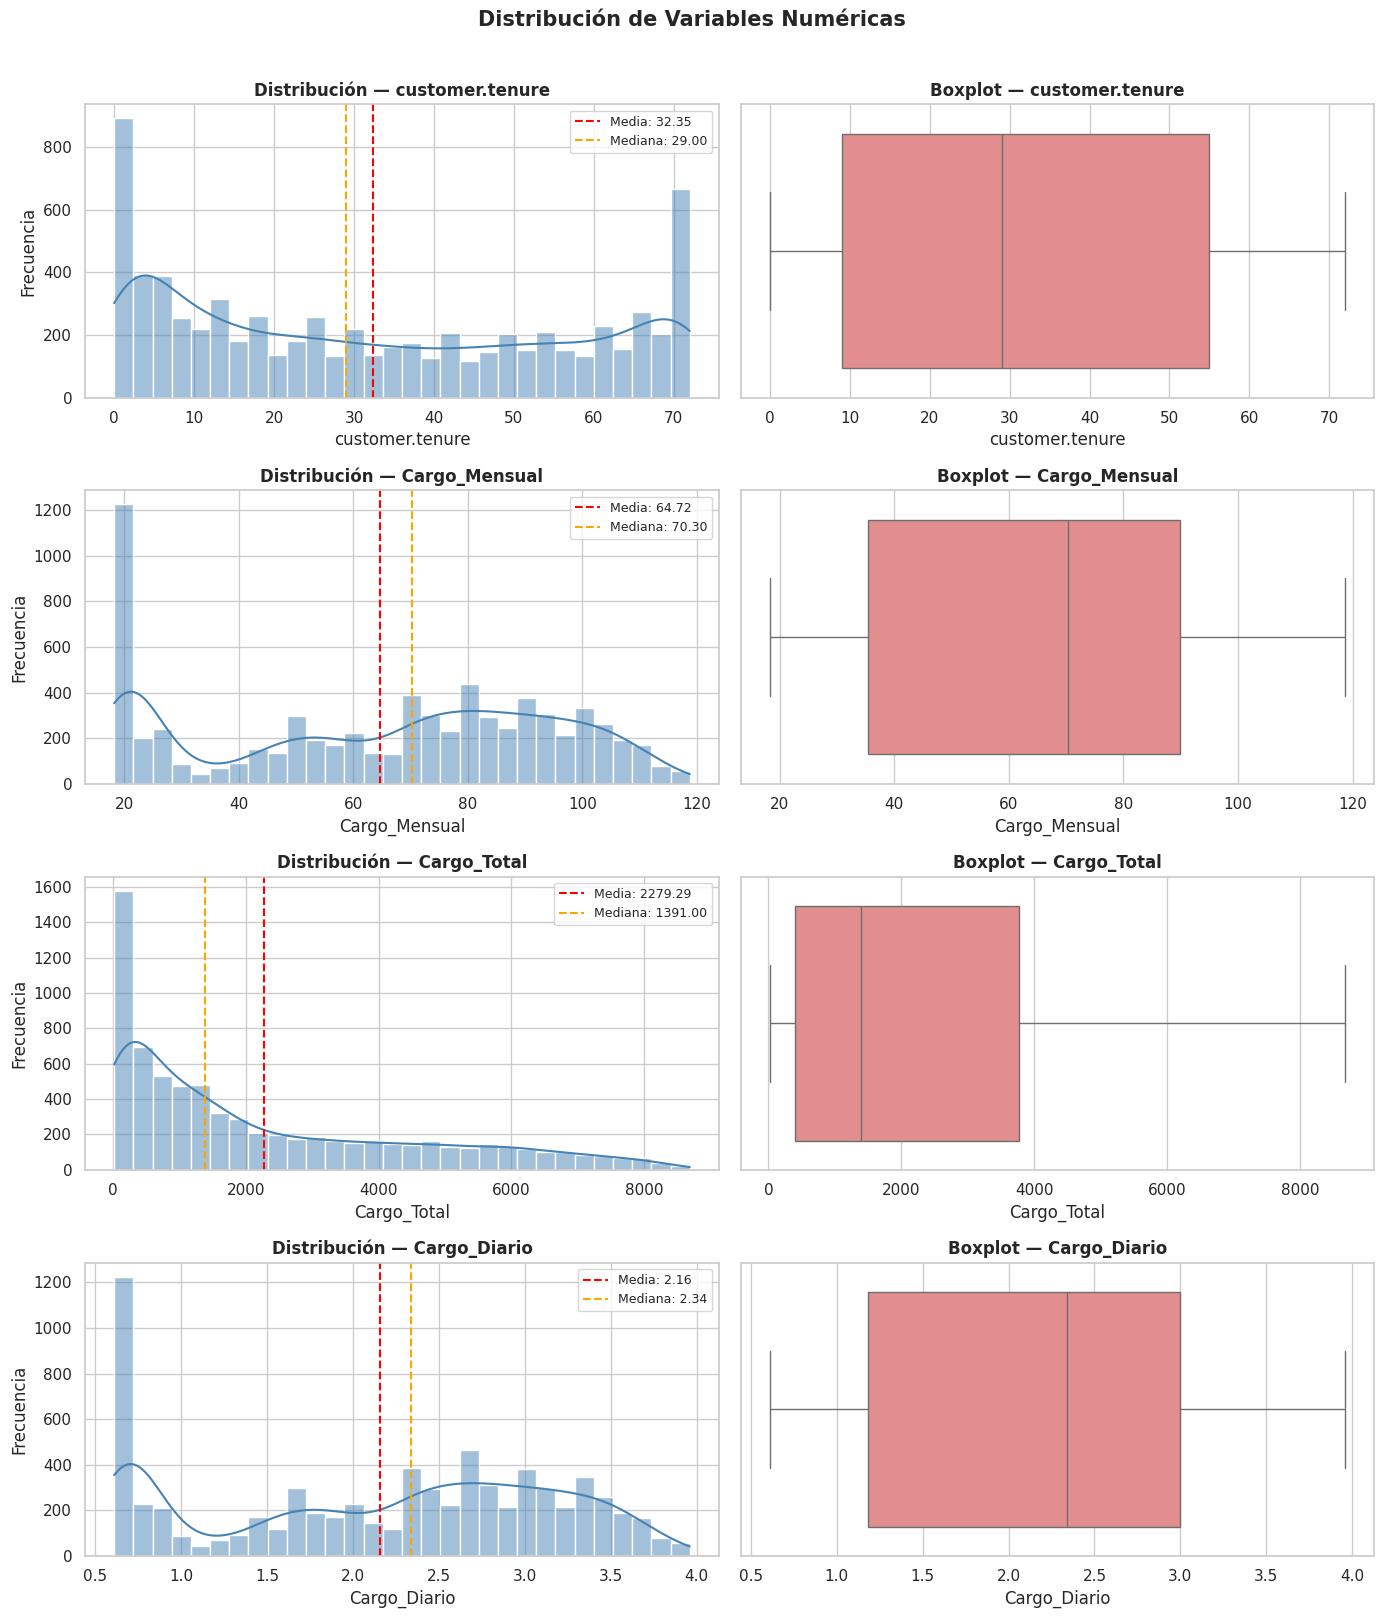

In [ ]:
try:
    cols_plot = [c for c in cols_num if df[c].nunique() > 5]

    if not cols_plot:
        print("  ⚠️  No hay columnas numéricas suficientes para graficar.")
    else:
        fig, axes = plt.subplots(
            nrows=len(cols_plot), ncols=2,
            figsize=(14, 4 * len(cols_plot))
        )
        # Asegurar que axes sea siempre 2D
        if len(cols_plot) == 1:
            axes = [axes]

        for i, col in enumerate(cols_plot):
            try:
                serie = df[col].dropna()

                # ── Histograma + KDE ───────────────────────────
                ax1 = axes[i][0]
                sns.histplot(serie, kde=True, ax=ax1, color='steelblue', bins=30)
                ax1.axvline(serie.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Media: {serie.mean():.2f}')
                ax1.axvline(serie.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {serie.median():.2f}')
                ax1.set_title(f'Distribución — {col}', fontsize=12, fontweight='bold')
                ax1.set_xlabel(col)
                ax1.set_ylabel('Frecuencia')
                ax1.legend(fontsize=9)

                # ── Boxplot ────────────────────────────────────
                ax2 = axes[i][1]
                sns.boxplot(x=serie, ax=ax2, color='lightcoral')
                ax2.set_title(f'Boxplot — {col}', fontsize=12, fontweight='bold')
                ax2.set_xlabel(col)

            except Exception as e:
                print(f"  ⚠️  Error graficando '{col}': {e}")

        plt.suptitle('Distribución de Variables Numéricas', fontsize=15, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.show()

except Exception as e:
    print(f"  ❌ Error en gráficas de distribución: {e}")



###6.3 Análisis de Variables Categóricas

In [ ]:
seccion("6.3 — ANÁLISIS DE VARIABLES CATEGÓRICAS")

try:
    cols_cat = [
        c for c in df.select_dtypes(include='object').columns
        if df[c].nunique() <= 20
    ]

    if not cols_cat:
        print("  ⚠️  No se encontraron columnas categóricas.")
    else:
        for col in cols_cat:
            try:
                conteo = df[col].value_counts()
                pct    = (conteo / len(df) * 100).round(1)

                tabla = pd.DataFrame({
                    'Cantidad'      : conteo,
                    'Porcentaje (%)': pct
                })
                print(f"\n  📌 {col}:")
                display(tabla)

            except Exception as e:
                print(f"  ⚠️  Error en '{col}': {e}")

except Exception as e:
    print(f"  ❌ Error en categóricas: {e}")



  6.3 — ANÁLISIS DE VARIABLES CATEGÓRICAS

  📌 Genero:


,Cantidad,Porcentaje (%)
Genero,,
Masculino,3675,50.6
Femenino,3592,49.4



  📌 Lineas_Multiples:


,Cantidad,Porcentaje (%)
Lineas_Multiples,,
No,3495,48.1
Si,3065,42.2
Sin Servicio,707,9.7



  📌 Tipo_Internet:


...

,Cantidad,Porcentaje (%)
Streaming_Peliculas,,
No,2870,39.5
Yes,2816,38.8
Sin Internet,1581,21.8



  📌 Tipo_Contrato:


,Cantidad,Porcentaje (%)
Tipo_Contrato,,
Mes a Mes,4005,55.1
Dos Años,1743,24.0
Un Año,1519,20.9



  📌 Metodo_Pago:


,Cantidad,Porcentaje (%)
Metodo_Pago,,
Cheque Electronico,2445,33.6
Cheque por Correo,1665,22.9
Transferencia Bancaria,1589,21.9
Tarjeta de Credito,1568,21.6


### 6.4 Gráficas de Variables Categóricas


  6.4 — GRÁFICAS DE VARIABLES CATEGÓRICAS


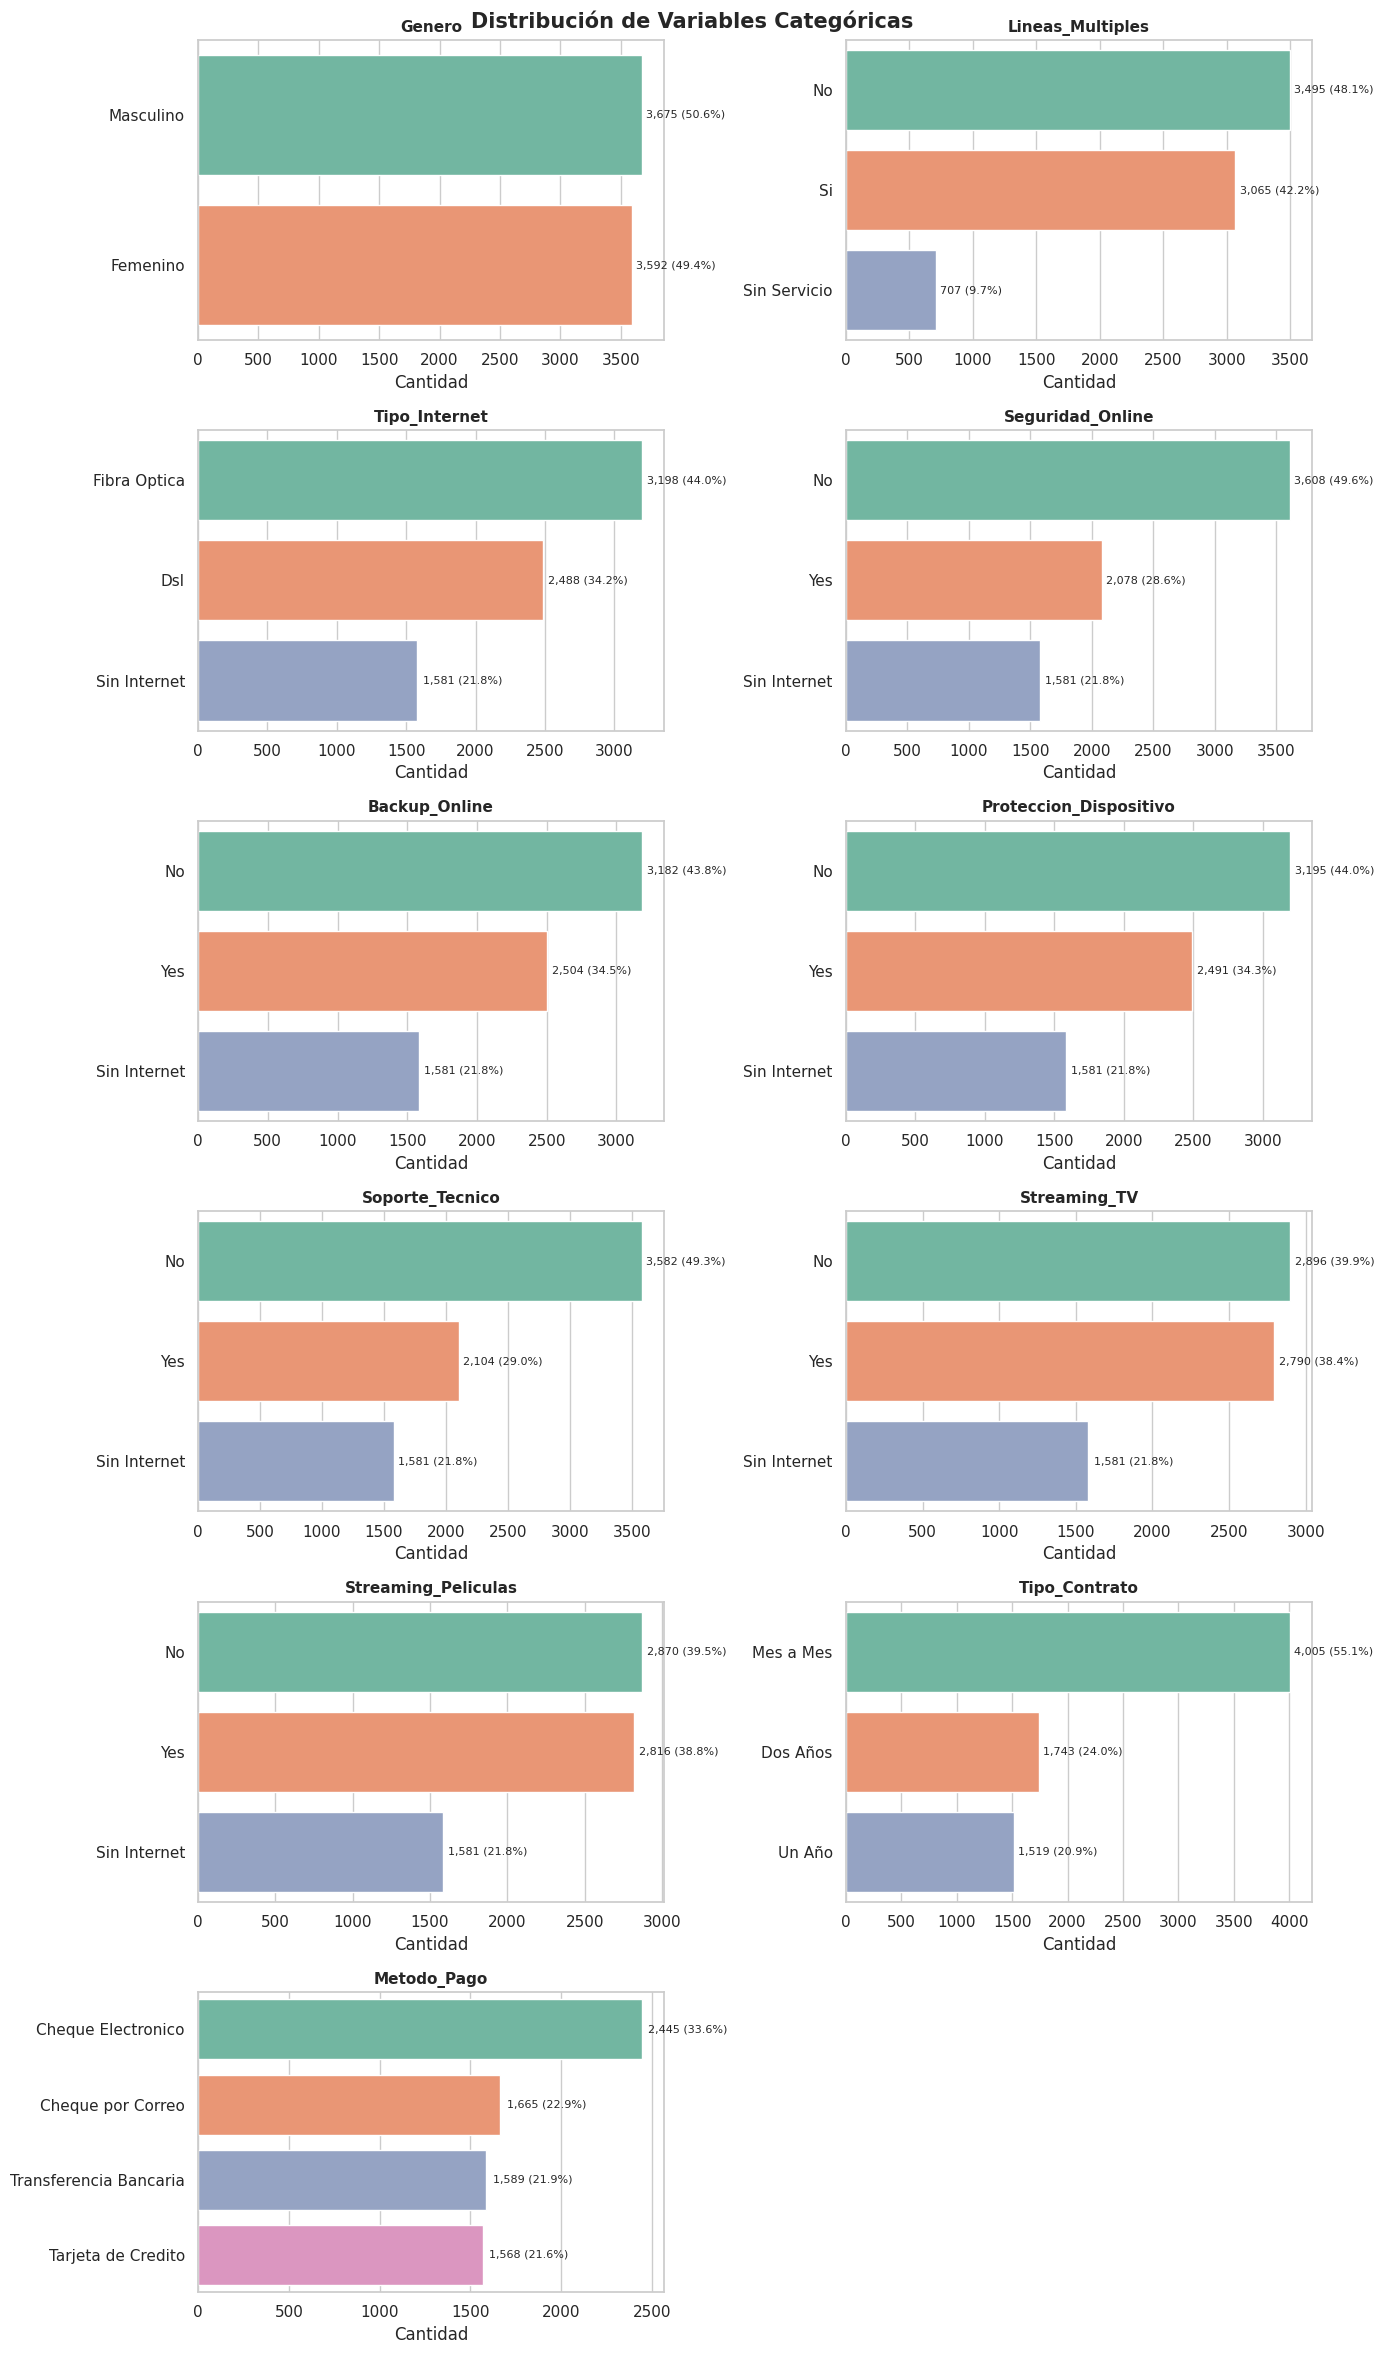

In [ ]:
seccion("6.4 — GRÁFICAS DE VARIABLES CATEGÓRICAS")

try:
    if not cols_cat:
        print("  ⚠️  No hay columnas categóricas para graficar.")
    else:
        n     = len(cols_cat)
        ncols = 2
        nrows = (n + 1) // ncols

        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4 * nrows))
        axes = axes.flatten()

        for i, col in enumerate(cols_cat):
            try:
                conteo = df[col].value_counts()
                sns.barplot(
                    x=conteo.values,
                    y=conteo.index.astype(str),
                    ax=axes[i],
                    palette='Set2'
                )
                axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
                axes[i].set_xlabel('Cantidad')
                axes[i].set_ylabel('')

                # Etiquetas de porcentaje en cada barra
                total = conteo.sum()
                for j, v in enumerate(conteo.values):
                    axes[i].text(
                        v + total * 0.005, j,
                        f'{v:,} ({v/total*100:.1f}%)',
                        va='center', fontsize=8
                    )
            except Exception as e:
                print(f"  ⚠️  Error graficando '{col}': {e}")

        # Ocultar ejes sobrantes
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle('Distribución de Variables Categóricas', fontsize=15, fontweight='bold')
        plt.tight_layout()
        plt.show()

except Exception as e:
    print(f"  ❌ Error en gráficas categóricas: {e}")


### 6.5 Análisis de la Variable objetivo(EVASIÓN)


  6.5 — VARIABLE OBJETIVO: EVASIÓN

  📌 Distribución de 'Evasion':

     Se quedó ✅      :  5398 clientes  (74.3%)  █████████████████████████████████████
     Se fue ❌        :  1869 clientes  (25.7%)  ████████████


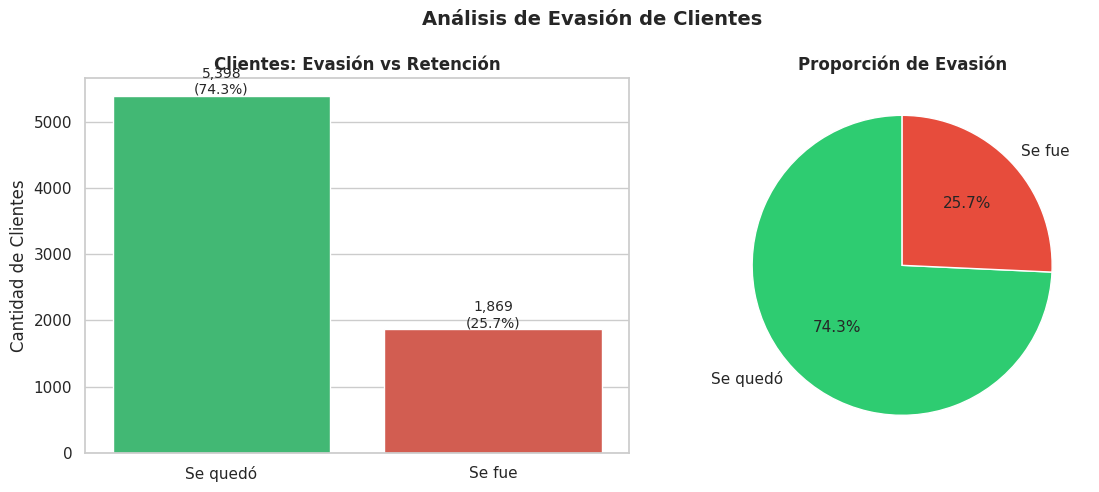

In [ ]:
seccion("6.5 — VARIABLE OBJETIVO: EVASIÓN")

try:
    col_objetivo = [c for c in df.columns if 'evasi' in c.lower() or 'churn' in c.lower()][0]
    conteo       = df[col_objetivo].value_counts()
    pct          = (conteo / len(df) * 100).round(1)

    print(f"\n  📌 Distribución de '{col_objetivo}':\n")
    for val, cnt in conteo.items():
        barra  = '█' * int(pct[val] / 2)
        etiq   = 'Se fue ❌' if val == 1 else 'Se quedó ✅'
        print(f"     {etiq:<15} : {cnt:>5} clientes  ({pct[val]}%)  {barra}")

    # ── Gráfica ────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Barras
    colores = ['#2ecc71', '#e74c3c']
    etiquetas = ['Se quedó', 'Se fue']
    sns.barplot(x=etiquetas, y=conteo.values, palette=colores, ax=ax1)
    ax1.set_title('Clientes: Evasión vs Retención', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Cantidad de Clientes')
    for j, v in enumerate(conteo.values):
        ax1.text(j, v + 30, f'{v:,}\n({pct.iloc[j]}%)', ha='center', fontsize=10)

    # Pie
    ax2.pie(
        conteo.values,
        labels=etiquetas,
        colors=colores,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 11}
    )
    ax2.set_title('Proporción de Evasión', fontsize=12, fontweight='bold')

    plt.suptitle('Análisis de Evasión de Clientes', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

except IndexError:
    print("  ⚠️  No se encontró la columna objetivo (Evasion/Churn)")
except Exception as e:
    print(f"  ❌ Error en análisis de evasión: {e}")


### 6.6 Resumen Descriptivo Final

In [ ]:
seccion("6.6 — RESUMEN DESCRIPTIVO FINAL")

try:
    col_objetivo = [c for c in df.columns if 'evasi' in c.lower() or 'churn' in c.lower()][0]
    tasa_evasion = (df[col_objetivo].sum() / len(df) * 100).round(1)

    col_mensual  = [c for c in df.columns if 'mensual' in c.lower() or 'monthly' in c.lower()][0]
    col_tenure   = [c for c in df.columns if 'meses' in c.lower() or 'tenure' in c.lower()][0]

    print(f"""
  ┌──────────────────────────────────────────────────┐
  │           RESUMEN DESCRIPTIVO DEL DATASET        │
  ├──────────────────────────────────────────────────┤
  │  👥 Total clientes          : {str(len(df)):>6} clientes    │
  │  ❌ Tasa de evasión         : {str(tasa_evasion):>6}%            │
  │  ✅ Tasa de retención       : {str(round(100 - tasa_evasion, 1)):>6}%            │
  ├──────────────────────────────────────────────────┤
  │  💰 Cargo mensual promedio  : ${str(round(df[col_mensual].mean(), 2)):>7}           │
  │  💰 Cargo mensual mediana   : ${str(round(df[col_mensual].median(), 2)):>7}           │
  │  📅 Permanencia promedio    : {str(round(df[col_tenure].mean(), 1)):>6} meses       │
  │  📅 Permanencia mediana     : {str(round(df[col_tenure].median(), 1)):>6} meses       │
  └──────────────────────────────────────────────────┘""")

    print("\n  👉 Siguiente paso: Análisis de Correlaciones y Factores de Evasión")

except Exception as e:
    print(f"  ❌ Error en resumen final: {e}")


  6.6 — RESUMEN DESCRIPTIVO FINAL

  ┌──────────────────────────────────────────────────┐
  │           RESUMEN DESCRIPTIVO DEL DATASET        │
  ├──────────────────────────────────────────────────┤
  │  👥 Total clientes          :   7267 clientes    │
  │  ❌ Tasa de evasión         :   25.7%            │
  │  ✅ Tasa de retención       :   74.3%            │
  ├──────────────────────────────────────────────────┤
  │  💰 Cargo mensual promedio  : $  64.72           │
  │  💰 Cargo mensual mediana   : $   70.3           │
  │  📅 Permanencia promedio    :   32.3 meses       │
  │  📅 Permanencia mediana     :   29.0 meses       │
  └──────────────────────────────────────────────────┘

  👉 Siguiente paso: Análisis de Correlaciones y Factores de Evasión


# Paso 7: Distribución de Evasión

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# ── Detectar columna objetivo ──────────────────────────────
try:
    col_objetivo = [
        c for c in df.columns
        if 'evasi' in c.lower() or 'churn' in c.lower()
    ][0]
    print(f"  📌 Columna objetivo detectada: '{col_objetivo}'")
except IndexError:
    raise ValueError("❌ No se encontró la columna Evasion/Churn.")

  📌 Columna objetivo detectada: 'Evasion'


### 7.1 Métricas Base

In [ ]:
seccion("7.1 — MÉTRICAS DE EVASIÓN")

try:
    total        = len(df)
    evadidos     = int(df[col_objetivo].sum())
    retenidos    = total - evadidos
    tasa_evasion = round(evadidos / total * 100, 1)
    tasa_ret     = round(100 - tasa_evasion, 1)

    print(f"""
  ┌─────────────────────────────────────────┐
  │         MÉTRICAS DE EVASIÓN             │
  ├─────────────────────────────────────────┤
  │  👥 Total de clientes  : {str(total):>6}         │
  │  ✅ Se quedaron        : {str(retenidos):>6} ({tasa_ret}%) │
  │  ❌ Se fueron          : {str(evadidos):>6} ({tasa_evasion}%) │
  └─────────────────────────────────────────┘""")

except Exception as e:
    print(f"  ❌ Error calculando métricas: {e}")


  7.1 — MÉTRICAS DE EVASIÓN

  ┌─────────────────────────────────────────┐
  │         MÉTRICAS DE EVASIÓN             │
  ├─────────────────────────────────────────┤
  │  👥 Total de clientes  :   7267         │
  │  ✅ Se quedaron        :   5398 (74.3%) │
  │  ❌ Se fueron          :   1869 (25.7%) │
  └─────────────────────────────────────────┘


### 7.2 Gráficas de Distribución


  7.2 — GRÁFICAS DE DISTRIBUCIÓN DE EVASIÓN


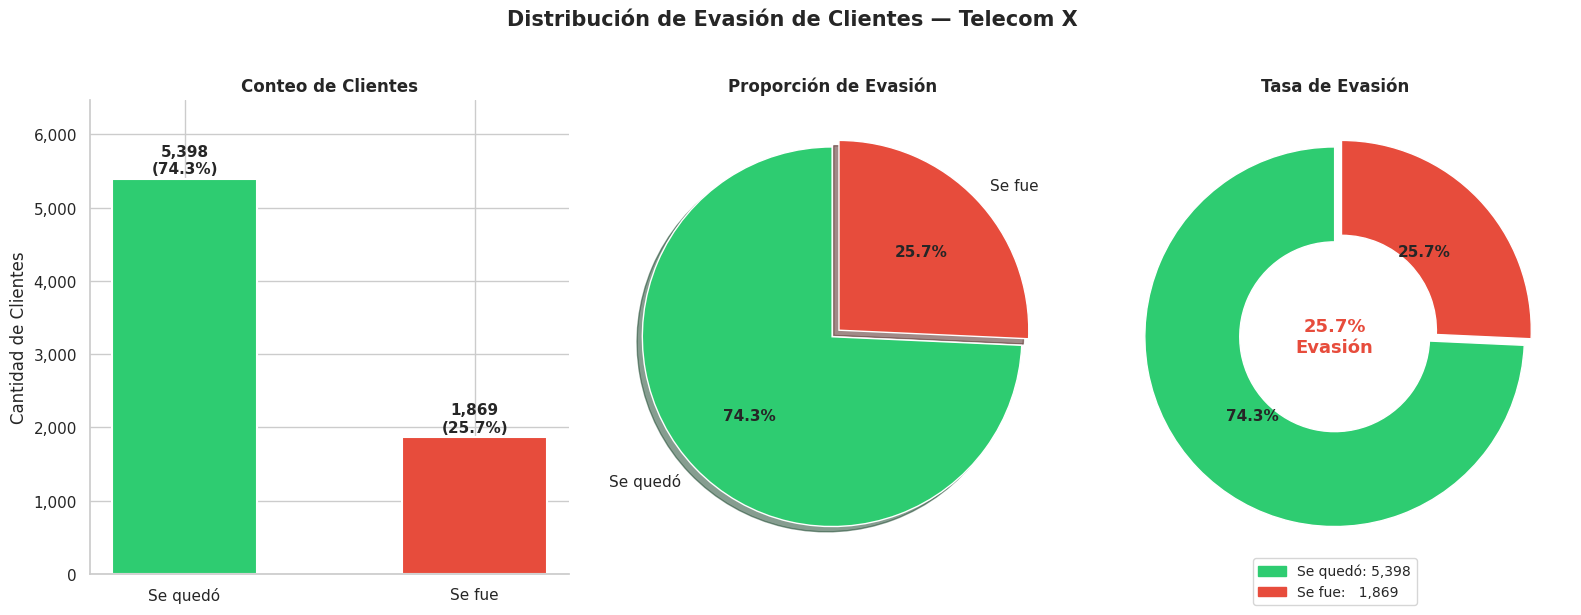

In [ ]:
seccion("7.2 — GRÁFICAS DE DISTRIBUCIÓN DE EVASIÓN")

try:
    COLORES     = ['#2ecc71', '#e74c3c']
    ETIQUETAS   = ['Se quedó', 'Se fue']
    VALORES     = [retenidos, evadidos]
    PORCENTAJES = [tasa_ret, tasa_evasion]

    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    fig.suptitle(
        'Distribución de Evasión de Clientes — Telecom X',
        fontsize=15, fontweight='bold', y=1.02
    )

    # ── Gráfica 1: Barras ─────────────────────────────────────
    try:
        ax1 = axes[0]
        barras = ax1.bar(ETIQUETAS, VALORES, color=COLORES, width=0.5, edgecolor='white', linewidth=1.5)

        for barra, val, pct in zip(barras, VALORES, PORCENTAJES):
            ax1.text(
                barra.get_x() + barra.get_width() / 2,
                barra.get_height() + 30,
                f'{val:,}\n({pct}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold'
            )

        ax1.set_title('Conteo de Clientes', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Cantidad de Clientes')
        ax1.set_ylim(0, max(VALORES) * 1.2)
        ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
        sns.despine(ax=ax1)

    except Exception as e:
        print(f"  ⚠️  Error en gráfica de barras: {e}")


    # ── Gráfica 2: Pie chart ──────────────────────────────────
    try:
        ax2 = axes[1]
        wedges, texts, autotexts = ax2.pie(
            VALORES,
            labels=ETIQUETAS,
            colors=COLORES,
            autopct='%1.1f%%',
            startangle=90,
            explode=(0, 0.05),
            shadow=True,
            textprops={'fontsize': 11}
        )
        for autotext in autotexts:
            autotext.set_fontweight('bold')

        ax2.set_title('Proporción de Evasión', fontsize=12, fontweight='bold')

    except Exception as e:
        print(f"  ⚠️  Error en pie chart: {e}")


    # ── Gráfica 3: Donut chart ────────────────────────────────
    try:
        ax3 = axes[2]
        wedges, texts, autotexts = ax3.pie(
            VALORES,
            colors=COLORES,
            autopct='%1.1f%%',
            startangle=90,
            explode=(0, 0.05),
            wedgeprops=dict(width=0.5),   # Hace el donut
            textprops={'fontsize': 11}
        )
        for autotext in autotexts:
            autotext.set_fontweight('bold')

        # Texto central del donut
        ax3.text(
            0, 0,
            f'{tasa_evasion}%\nEvasión',
            ha='center', va='center',
            fontsize=13, fontweight='bold', color='#e74c3c'
        )

        leyenda = [
            mpatches.Patch(color=COLORES[0], label=f'Se quedó: {retenidos:,}'),
            mpatches.Patch(color=COLORES[1], label=f'Se fue:   {evadidos:,}')
        ]
        ax3.legend(handles=leyenda, loc='lower center',
                   bbox_to_anchor=(0.5, -0.08), fontsize=10)
        ax3.set_title('Tasa de Evasión', fontsize=12, fontweight='bold')

    except Exception as e:
        print(f"  ⚠️  Error en donut chart: {e}")

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"  ❌ Error general en gráficas: {e}")

###Evasión por Variable Categórica


  7.3 — EVASIÓN SEGÚN VARIABLES CATEGÓRICAS


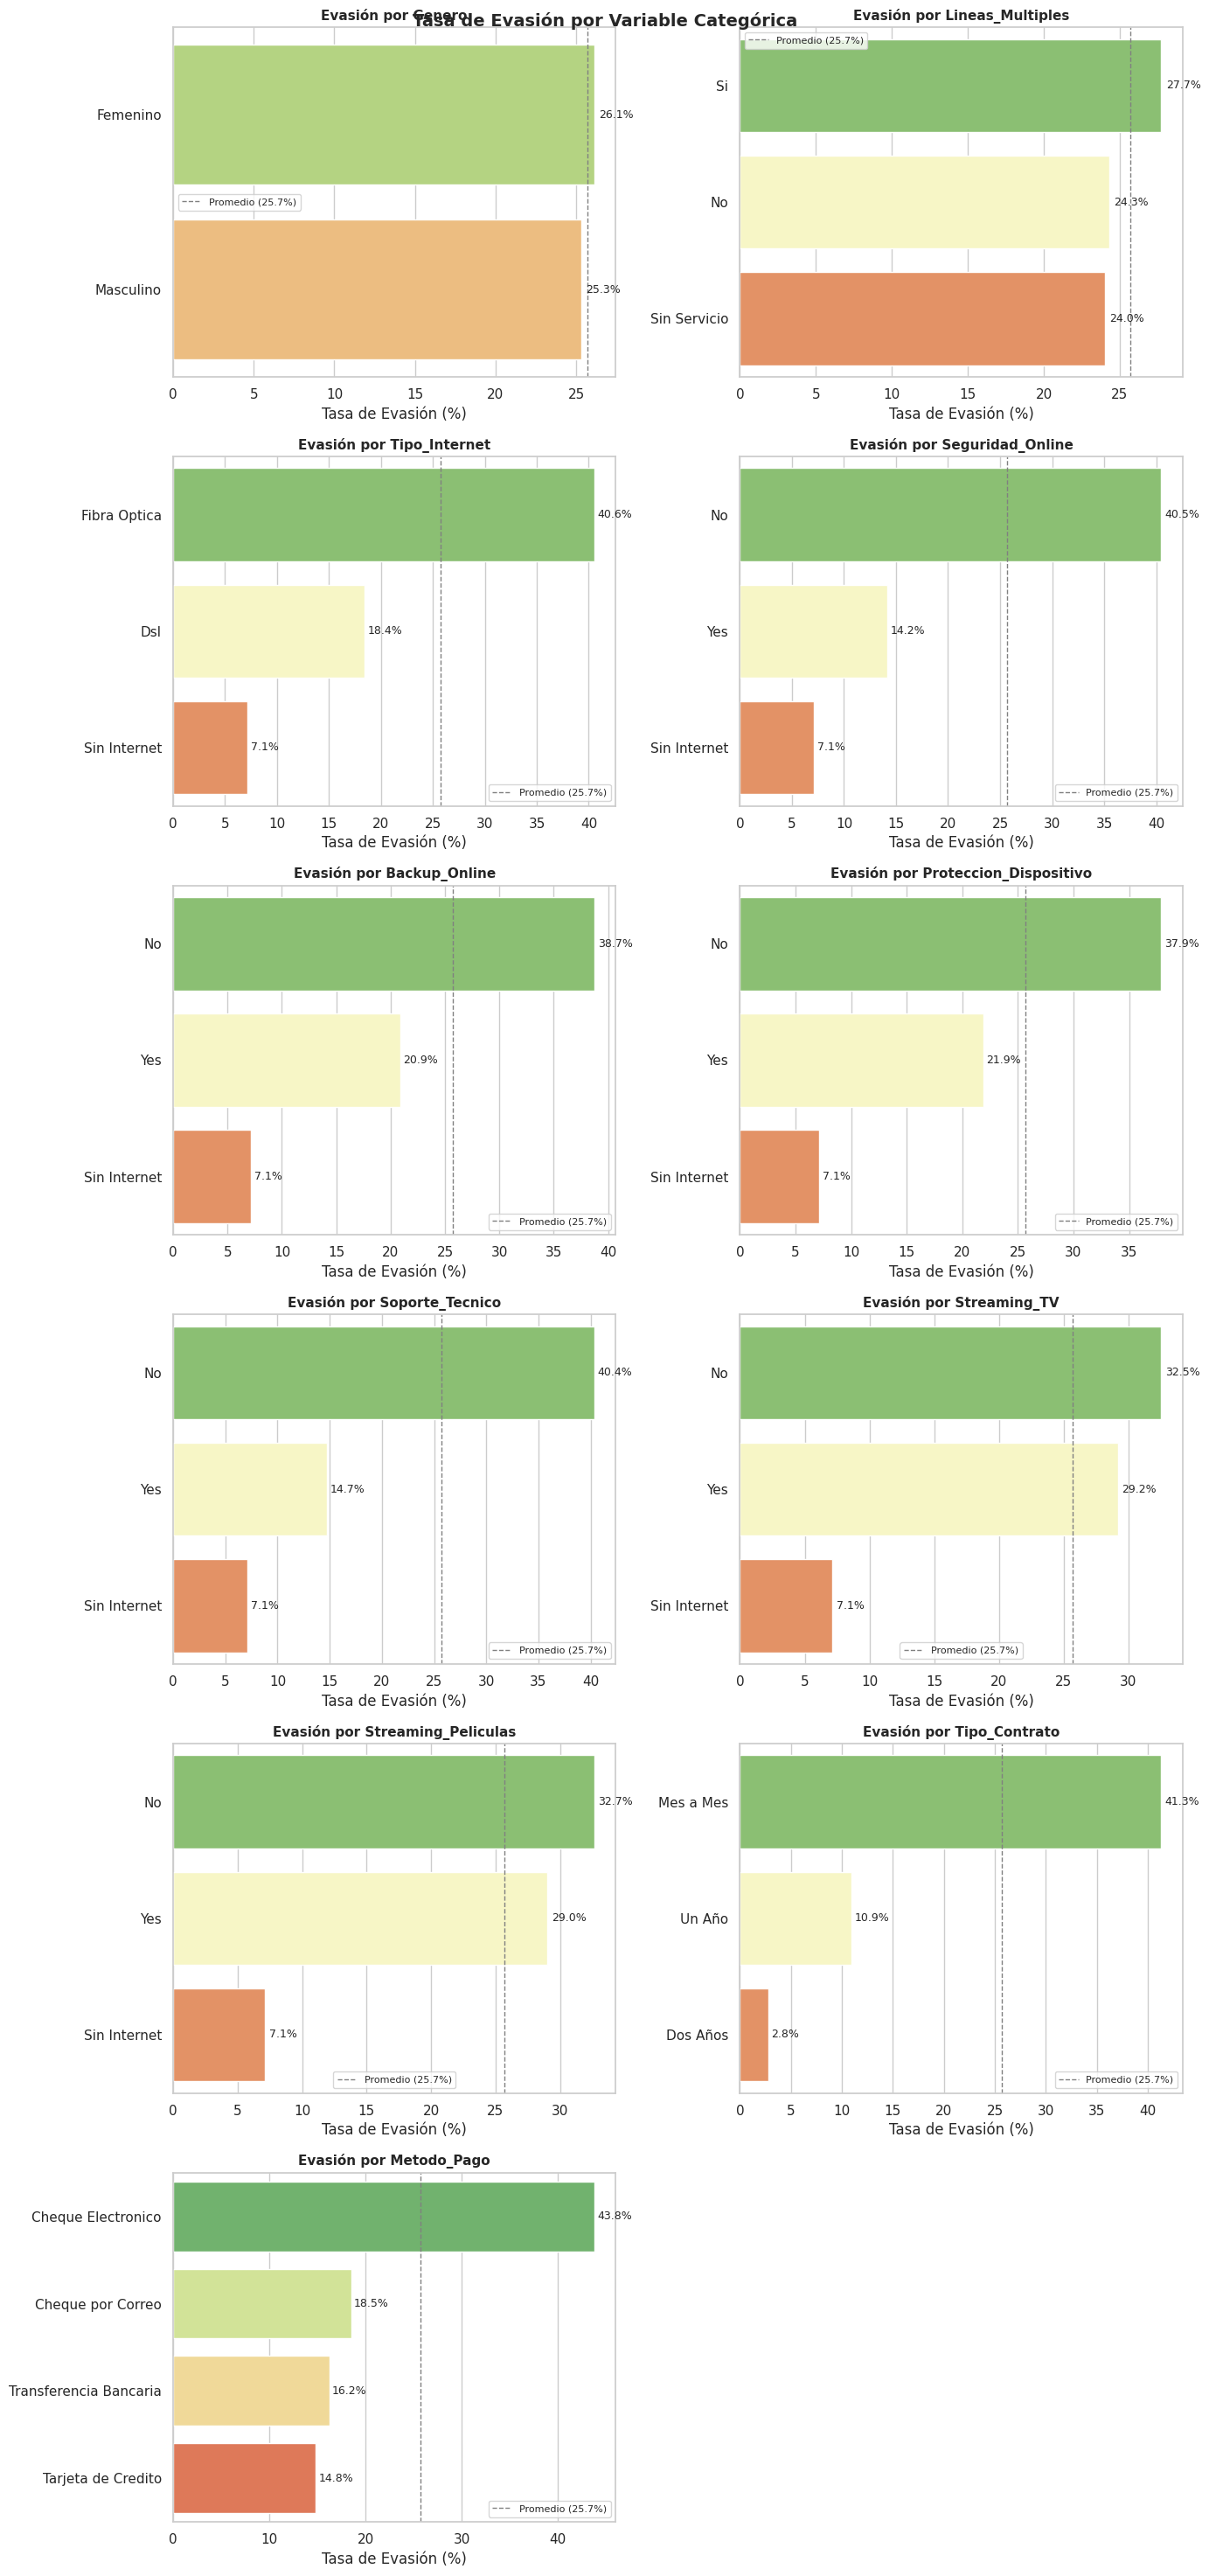

In [ ]:
seccion("7.3 — EVASIÓN SEGÚN VARIABLES CATEGÓRICAS")

try:
    cols_cat = [
        c for c in df.select_dtypes(include='object').columns
        if df[c].nunique() <= 10 and c != col_objetivo
    ]

    if not cols_cat:
        print("  ⚠️  No se encontraron columnas categóricas para comparar.")
    else:
        ncols = 2
        nrows = (len(cols_cat) + 1) // ncols
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 5 * nrows))
        axes = axes.flatten()

        fig.suptitle(
            'Tasa de Evasión por Variable Categórica',
            fontsize=14, fontweight='bold'
        )

        for i, col in enumerate(cols_cat):
            try:
                tasa = df.groupby(col)[col_objetivo].mean().sort_values(ascending=False) * 100

                sns.barplot(
                    x=tasa.values,
                    y=tasa.index.astype(str),
                    ax=axes[i],
                    palette='RdYlGn_r'
                )
                axes[i].set_title(f'Evasión por {col}', fontsize=11, fontweight='bold')
                axes[i].set_xlabel('Tasa de Evasión (%)')
                axes[i].set_ylabel('')
                axes[i].axvline(tasa_evasion, color='gray',
                                linestyle='--', linewidth=1,
                                label=f'Promedio ({tasa_evasion}%)')
                axes[i].legend(fontsize=8)

                for j, val in enumerate(tasa.values):
                    axes[i].text(val + 0.3, j, f'{val:.1f}%', va='center', fontsize=9)

            except Exception as e:
                print(f"  ⚠️  Error en '{col}': {e}")

        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()
        plt.show()

except Exception as e:
    print(f"  ❌ Error en evasión por categoría: {e}")


### 7.5 Evasión por Variables Numéricas

In [ ]:
seccion("7.5 — EVASIÓN POR VARIABLES NUMÉRICAS")

try:
    cols_num = [
        c for c in df.select_dtypes(include=[np.number]).columns
        if c != col_objetivo and df[c].nunique() > 5
    ]

    if not cols_num:
        print("  ⚠️  No se encontraron columnas numéricas para analizar.")
    else:
        print(f"  📌 Analizando {len(cols_num)} variable(s) numérica(s): {cols_num}")

except Exception as e:
    print(f"  ❌ Error detectando columnas numéricas: {e}")




  7.5 — EVASIÓN POR VARIABLES NUMÉRICAS
  📌 Analizando 4 variable(s) numérica(s): ['customer.tenure', 'Cargo_Mensual', 'Cargo_Total', 'Cargo_Diario']


####7.5.1 Estadisticas por grupo de evasión

In [ ]:
# ============================================================
# 7.5.1 — ESTADÍSTICAS POR GRUPO DE EVASIÓN
# ============================================================

seccion("7.5.1 — ESTADÍSTICAS: EVADIDOS vs RETENIDOS")

try:
    df_evadidos  = df[df[col_objetivo] == 1]
    df_retenidos = df[df[col_objetivo] == 0]

    stats_comparacion = []

    for col in cols_num:
        try:
            stats_comparacion.append({
                'Variable'              : col,
                'Media — Se quedó'      : round(df_retenidos[col].mean(), 2),
                'Media — Se fue'        : round(df_evadidos[col].mean(), 2),
                'Diferencia'            : round(df_evadidos[col].mean() - df_retenidos[col].mean(), 2),
                'Mediana — Se quedó'    : round(df_retenidos[col].median(), 2),
                'Mediana — Se fue'      : round(df_evadidos[col].median(), 2),
            })
        except Exception as e:
            print(f"  ⚠️  Error en '{col}': {e}")

    df_comp = pd.DataFrame(stats_comparacion).set_index('Variable')
    display(df_comp)

    # ── Detectar variables con mayor diferencia ────────────────
    print("\n  📊 Variables con mayor diferencia entre grupos:\n")
    try:
        top = df_comp['Diferencia'].abs().sort_values(ascending=False)
        for var, dif in top.items():
            direccion = "⬆️  Mayor en evadidos" if df_comp.loc[var, 'Diferencia'] > 0 else "⬇️  Menor en evadidos"
            print(f"     → '{var}': diferencia de {dif:.2f}  ({direccion})")
    except Exception as e:
        print(f"  ⚠️  Error detectando diferencias: {e}")

except Exception as e:
    print(f"  ❌ Error en estadísticas comparativas: {e}")


  7.5.1 — ESTADÍSTICAS: EVADIDOS vs RETENIDOS


,Media — Se quedó,Media — Se fue,Diferencia,Mediana — Se quedó,Mediana — Se fue
Variable,,,,,
customer.tenure,37.32,17.98,-19.34,37.00,10.00
Cargo_Mensual,61.35,74.44,13.09,64.50,79.65
Cargo_Total,2538.10,1531.80,-1006.30,1663.62,703.55
Cargo_Diario,2.05,2.48,0.44,2.15,2.66



  📊 Variables con mayor diferencia entre grupos:

     → 'Cargo_Total': diferencia de 1006.30  (⬇️  Menor en evadidos)
     → 'customer.tenure': diferencia de 19.34  (⬇️  Menor en evadidos)
     → 'Cargo_Mensual': diferencia de 13.09  (⬆️  Mayor en evadidos)
     → 'Cargo_Diario': diferencia de 0.44  (⬆️  Mayor en evadidos)


#### 7.5.2 Histograma por grupo de Evasión


  7.5.2 — HISTOGRAMAS POR GRUPO DE EVASIÓN


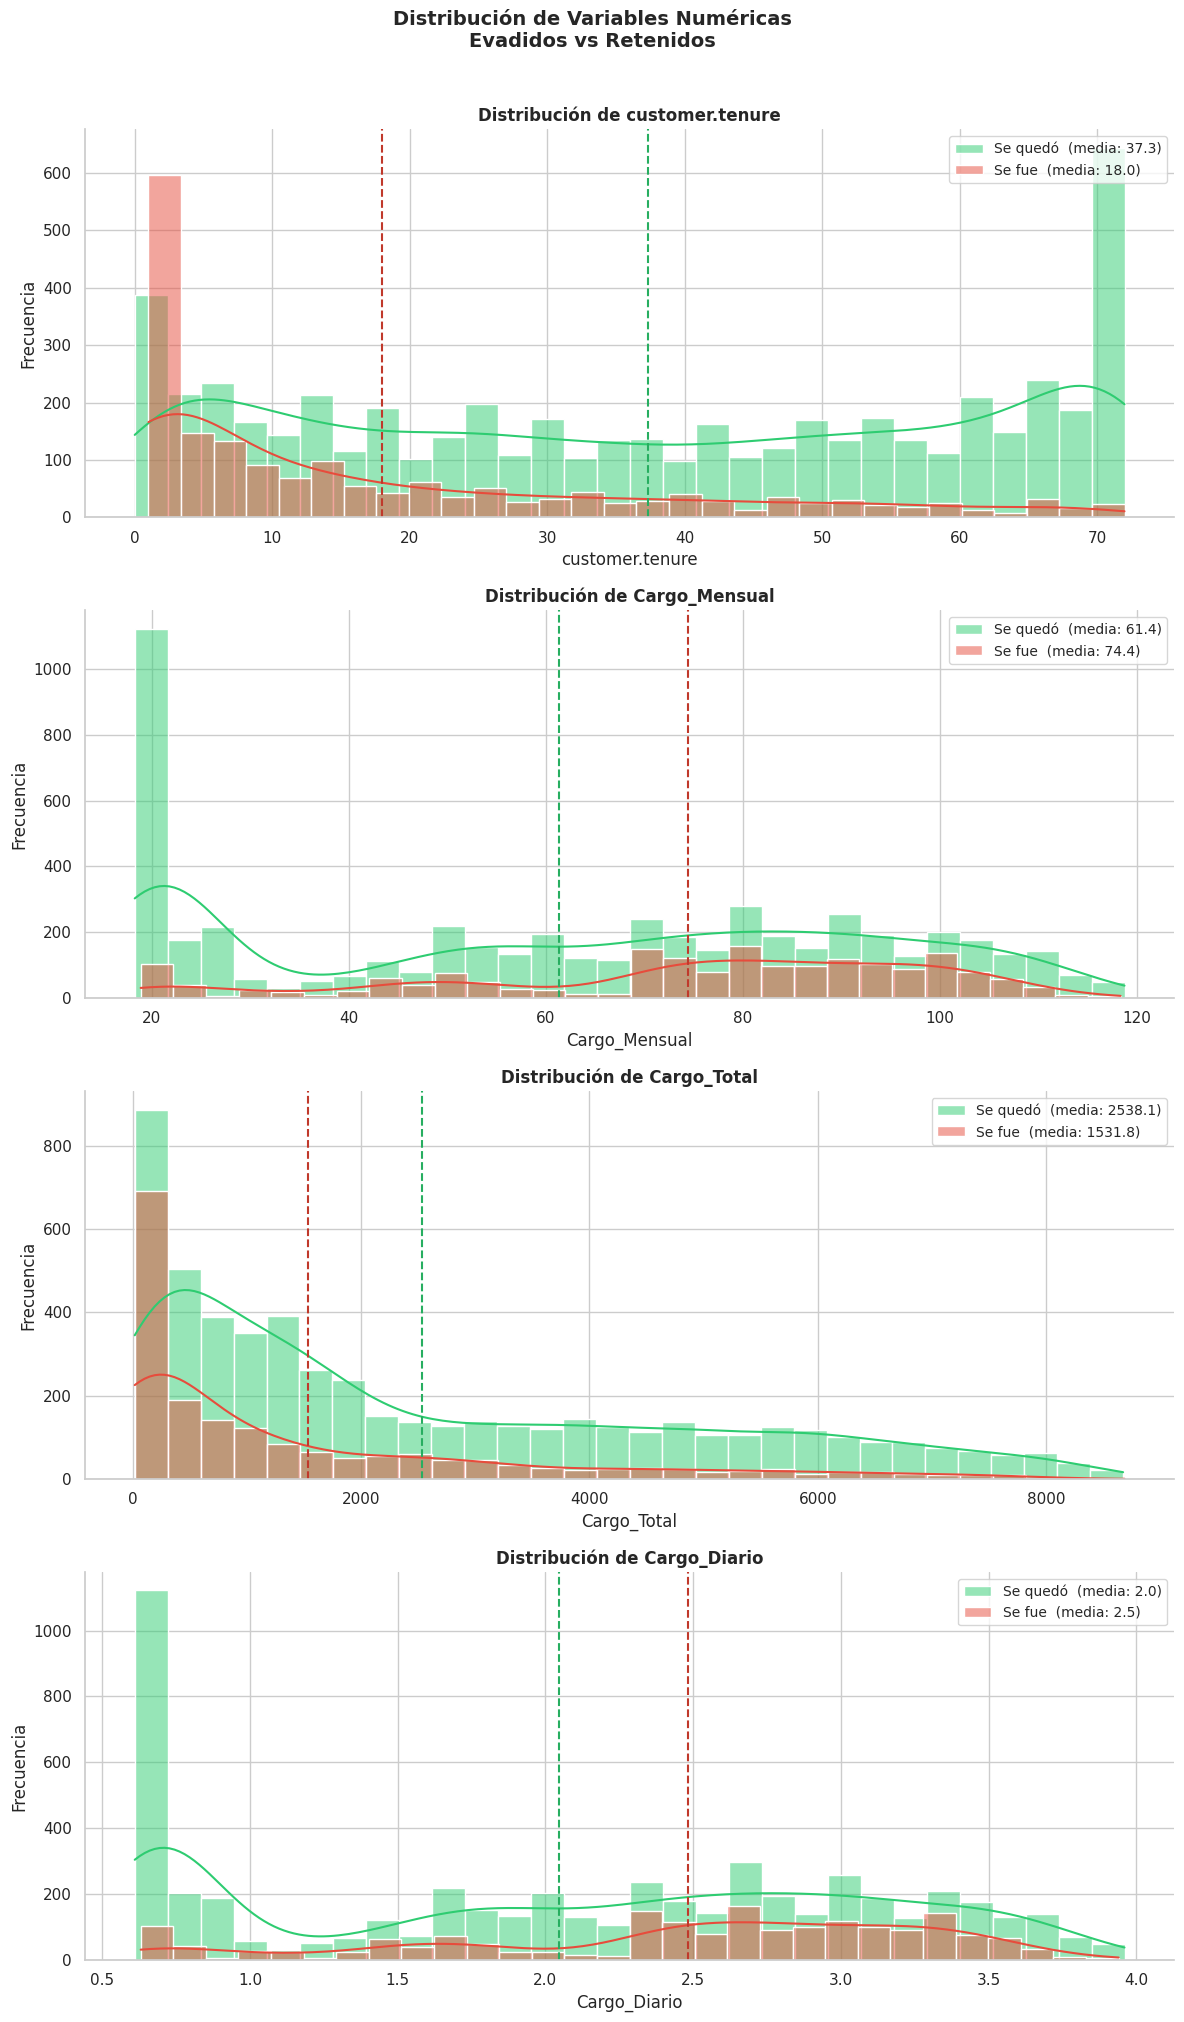

In [ ]:
# ============================================================
# 7.5.2 — HISTOGRAMAS POR GRUPO DE EVASIÓN
# ============================================================

seccion("7.5.2 — HISTOGRAMAS POR GRUPO DE EVASIÓN")

try:
    fig, axes = plt.subplots(
        nrows=len(cols_num), ncols=1,
        figsize=(12, 5 * len(cols_num))
    )

    # Asegurar que axes sea siempre iterable
    if len(cols_num) == 1:
        axes = [axes]

    fig.suptitle(
        'Distribución de Variables Numéricas\nEvadidos vs Retenidos',
        fontsize=14, fontweight='bold', y=1.01
    )

    for i, col in enumerate(cols_num):
        try:
            ax = axes[i]

            # Histograma retenidos
            sns.histplot(
                df_retenidos[col].dropna(),
                ax=ax, kde=True,
                color='#2ecc71', alpha=0.5,
                label=f'Se quedó  (media: {df_retenidos[col].mean():.1f})',
                bins=30
            )

            # Histograma evadidos
            sns.histplot(
                df_evadidos[col].dropna(),
                ax=ax, kde=True,
                color='#e74c3c', alpha=0.5,
                label=f'Se fue  (media: {df_evadidos[col].mean():.1f})',
                bins=30
            )

            # Líneas de media
            ax.axvline(df_retenidos[col].mean(), color='#27ae60',
                       linestyle='--', linewidth=1.5)
            ax.axvline(df_evadidos[col].mean(),  color='#c0392b',
                       linestyle='--', linewidth=1.5)

            ax.set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
            ax.set_xlabel(col)
            ax.set_ylabel('Frecuencia')
            ax.legend(fontsize=10)
            sns.despine(ax=ax)

        except Exception as e:
            print(f"  ⚠️  Error graficando histograma '{col}': {e}")

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"  ❌ Error en histogramas: {e}")

#### 7.5.3 Boxplots por grupo de Evasión


  7.5.3 — BOXPLOTS POR GRUPO DE EVASIÓN


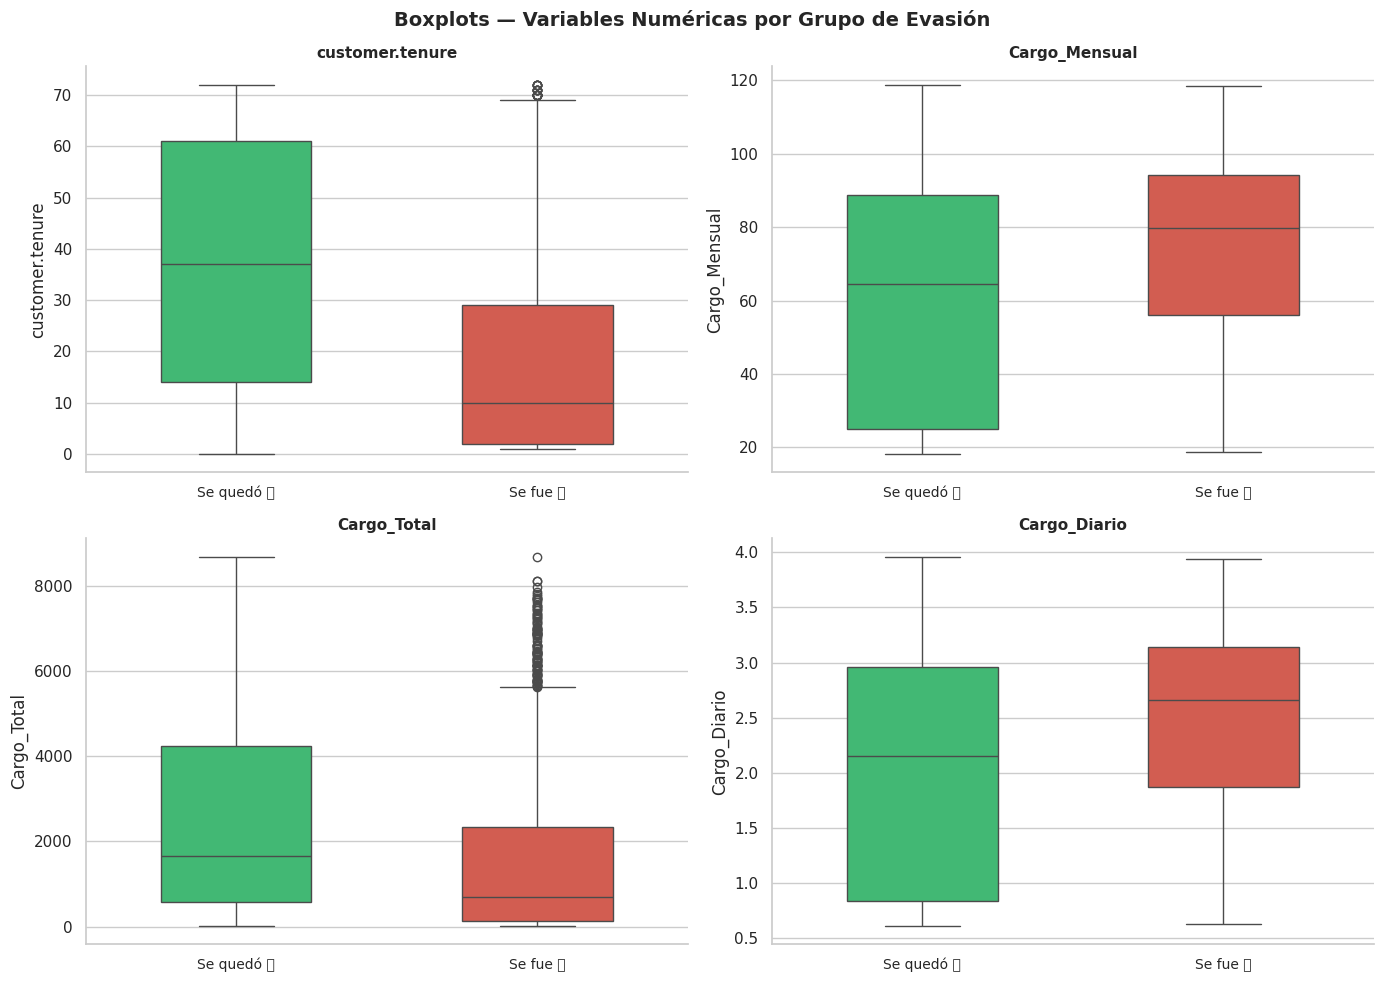

In [ ]:
seccion("7.5.3 — BOXPLOTS POR GRUPO DE EVASIÓN")

try:
    # ✅ Fix definitivo: paleta con claves string '0' y '1'
    # Seaborn siempre convierte los valores del eje X a string internamente
    paleta    = {'0': '#2ecc71', '1': '#e74c3c'}

    ncols = 2
    nrows = (len(cols_num) + 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 5 * nrows))
    axes = axes.flatten()

    fig.suptitle(
        'Boxplots — Variables Numéricas por Grupo de Evasión',
        fontsize=14, fontweight='bold'
    )

    for i, col in enumerate(cols_num):
        try:
            sns.boxplot(
                data=df,
                x=col_objetivo,
                y=col,
                ax=axes[i],
                palette=paleta,
                width=0.5,
                order=[0, 1]
            )
            axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
            axes[i].set_xlabel('')
            axes[i].set_ylabel(col)
            axes[i].set_xticks([0, 1])
            axes[i].set_xticklabels(['Se quedó ✅', 'Se fue ❌'], fontsize=10)
            sns.despine(ax=axes[i])

        except Exception as e:
            print(f"  ⚠️  Error en boxplot '{col}': {e}")

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"  ❌ Error en boxplots: {e}")

#### 7.5.4 Análisis por segmentos (Rangos)


  7.5.4 — TASA DE EVASIÓN POR SEGMENTO


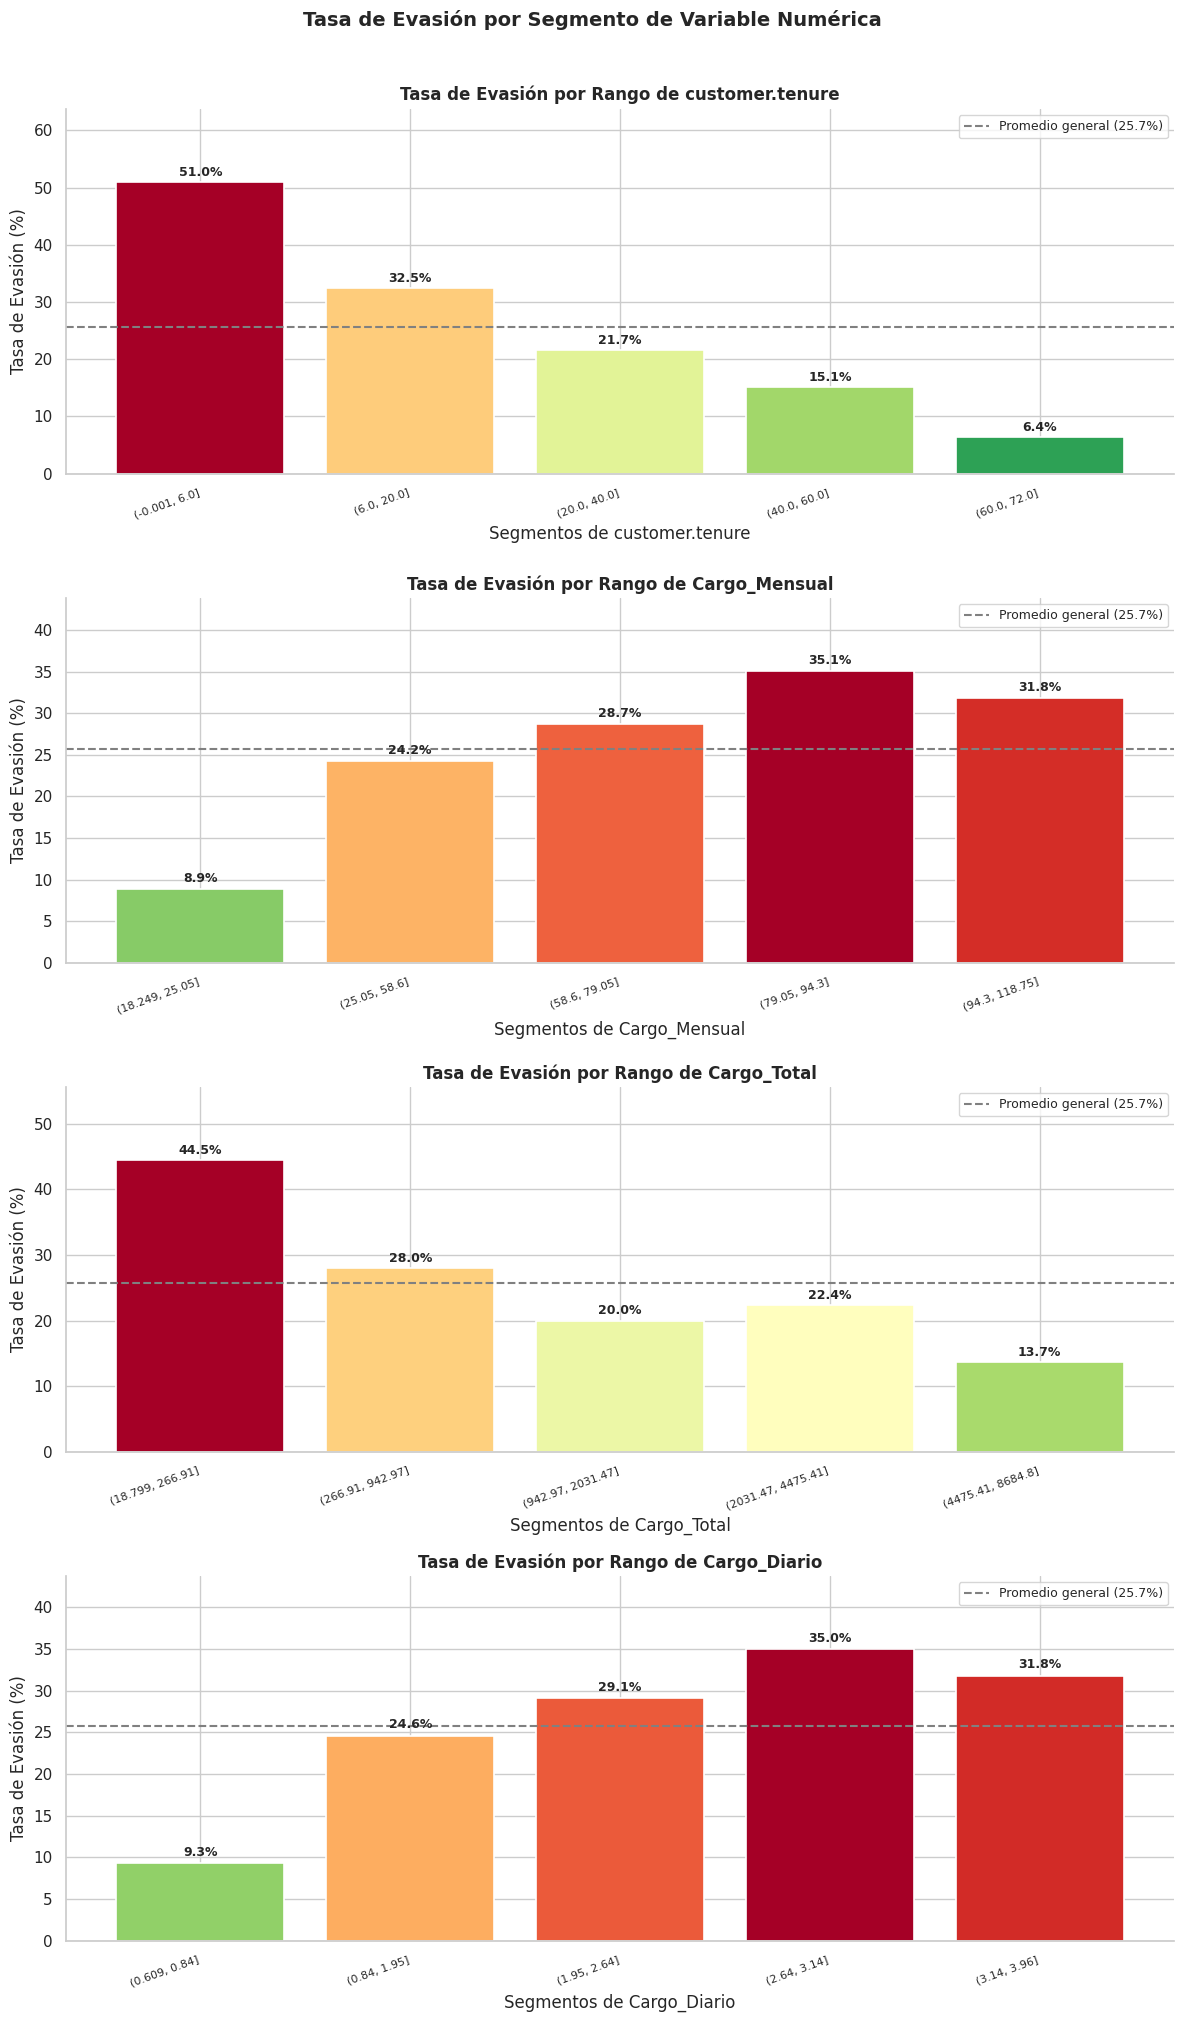

In [ ]:
# ============================================================
# 7.5.4 — ANÁLISIS POR SEGMENTOS (RANGOS)
# ============================================================

seccion("7.5.4 — TASA DE EVASIÓN POR SEGMENTO")

try:
    fig, axes = plt.subplots(
        nrows=len(cols_num), ncols=1,
        figsize=(12, 5 * len(cols_num))
    )

    if len(cols_num) == 1:
        axes = [axes]

    fig.suptitle(
        'Tasa de Evasión por Segmento de Variable Numérica',
        fontsize=14, fontweight='bold', y=1.01
    )

    for i, col in enumerate(cols_num):
        try:
            ax = axes[i]

            # Crear 5 segmentos iguales
            df['_segmento'] = pd.qcut(df[col], q=5, duplicates='drop')
            tasa_segmento   = df.groupby('_segmento', observed=True)[col_objetivo]\
                                .mean()\
                                .mul(100)\
                                .round(1)\
                                .reset_index()
            tasa_segmento.columns = ['Segmento', 'Tasa_Evasion']
            tasa_segmento['Segmento'] = tasa_segmento['Segmento'].astype(str)

            barras = ax.bar(
                tasa_segmento['Segmento'],
                tasa_segmento['Tasa_Evasion'],
                color=plt.cm.RdYlGn_r(
                    tasa_segmento['Tasa_Evasion'] / tasa_segmento['Tasa_Evasion'].max()
                ),
                edgecolor='white', linewidth=1.2
            )

            # Línea de promedio general
            ax.axhline(tasa_evasion, color='gray', linestyle='--',
                       linewidth=1.5, label=f'Promedio general ({tasa_evasion}%)')

            # Etiquetas encima de cada barra
            for barra, val in zip(barras, tasa_segmento['Tasa_Evasion']):
                ax.text(
                    barra.get_x() + barra.get_width() / 2,
                    barra.get_height() + 0.5,
                    f'{val:.1f}%',
                    ha='center', va='bottom', fontsize=9, fontweight='bold'
                )

            ax.set_title(f'Tasa de Evasión por Rango de {col}',
                         fontsize=12, fontweight='bold')
            ax.set_xlabel(f'Segmentos de {col}')
            ax.set_ylabel('Tasa de Evasión (%)')
            ax.set_ylim(0, tasa_segmento['Tasa_Evasion'].max() * 1.25)
            ax.legend(fontsize=9)
            plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
            sns.despine(ax=ax)

        except Exception as e:
            print(f"  ⚠️  Error en segmentos '{col}': {e}")

    # Eliminar columna temporal
    df.drop(columns=['_segmento'], inplace=True, errors='ignore')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"  ❌ Error en análisis por segmentos: {e}")

#### 7.5.5 Resumen de Hallazgos-- Variables Numéricas

In [ ]:
seccion("7.5.5 — HALLAZGOS CLAVE — VARIABLES NUMÉRICAS")

try:
    print("  📊 Comportamiento de clientes evadidos vs retenidos:\n")

    for col in cols_num:
        try:
            media_ret  = df_retenidos[col].mean()
            media_evad = df_evadidos[col].mean()
            dif        = media_evad - media_ret
            direccion  = "más alto" if dif > 0 else "más bajo"
            icono      = "🔴" if dif > 0 else "🟢"

            print(f"  {icono} '{col}':")
            print(f"      Se quedó : {media_ret:.2f}  |  Se fue : {media_evad:.2f}  "
                  f"→ {abs(dif):.2f} {direccion} en evadidos")
        except Exception as e:
            print(f"  ⚠️  Error en '{col}': {e}")

    print(f"\n  👉 Siguiente paso: Análisis de Correlaciones")

except Exception as e:
    print(f"  ❌ Error en hallazgos: {e}")


  7.5.5 — HALLAZGOS CLAVE — VARIABLES NUMÉRICAS
  📊 Comportamiento de clientes evadidos vs retenidos:

  🟢 'customer.tenure':
      Se quedó : 37.32  |  Se fue : 17.98  → 19.34 más bajo en evadidos
  🔴 'Cargo_Mensual':
      Se quedó : 61.35  |  Se fue : 74.44  → 13.09 más alto en evadidos
  🟢 'Cargo_Total':
      Se quedó : 2538.10  |  Se fue : 1531.80  → 1006.30 más bajo en evadidos
  🔴 'Cargo_Diario':
      Se quedó : 2.05  |  Se fue : 2.48  → 0.44 más alto en evadidos

  👉 Siguiente paso: Análisis de Correlaciones


# Resumen Final

In [ ]:
# ============================================================
# TELECOM X — INFORME FINAL DE ANÁLISIS DE EVASIÓN
# ============================================================

from IPython.display import display, Markdown

def md(texto):
    display(Markdown(texto))


# ============================================================
# PORTADA
# ============================================================

md("""
---
# 📊 TELECOM X — Informe Final de Análisis de Evasión de Clientes
**Proyecto:** Churn de Clientes | **Área:** Data Science | **Herramienta:** Python / Google Colab

---
""")


# ============================================================
# 1. INTRODUCCIÓN
# ============================================================

md("## 🎯 1. Introducción")

try:
    tasa_evasion     = round(df[col_objetivo].sum() / len(df) * 100, 1)
    tasa_retencion   = round(100 - tasa_evasion, 1)
    total_clientes   = len(df)
    total_evadidos   = int(df[col_objetivo].sum())
    total_retenidos  = total_clientes - total_evadidos

    md(f"""
Telecom X enfrenta una **tasa de evasión del {tasa_evasion}%**, lo que representa
**{total_evadidos:,} clientes perdidos** de un total de {total_clientes:,}.

El objetivo de este análisis es identificar los factores que llevan a los clientes
a cancelar el servicio, para que el equipo de Data Science pueda desarrollar
modelos predictivos y estrategias de retención efectivas.

| Métrica | Valor |
|---|---|
| 👥 Total de clientes | {total_clientes:,} |
| ✅ Clientes retenidos | {total_retenidos:,} ({tasa_retencion}%) |
| ❌ Clientes evadidos | {total_evadidos:,} ({tasa_evasion}%) |
""")

except Exception as e:
    print(f"⚠️  Error en introducción: {e}")


# ============================================================
# 2. LIMPIEZA Y TRATAMIENTO DE DATOS
# ============================================================

md("## 🧹 2. Limpieza y Tratamiento de Datos")

try:
    filas_originales = len(df_original) if 'df_original' in dir() else 'N/A'
    cols_originales  = df_original.shape[1] if 'df_original' in dir() else 'N/A'

    md(f"""
Los datos fueron obtenidos desde la API de Telecom X en formato JSON
y procesados con `pd.json_normalize()` para aplanar estructuras anidadas.

### 📥 Datos originales
- **{filas_originales} filas** y **{cols_originales} columnas** al momento de la importación.

### 🔍 Problemas detectados y corregidos

| Problema | Acción aplicada |
|---|---|
| Nulos disfrazados (`'none'`, `'null'`, `'-'`) | Reemplazados por `NaN` real |
| Columna `Churn` con 224 NaN | Filas **eliminadas** — variable objetivo no se imputa |
| `Charges.Total` como texto | Convertida a tipo numérico — NaN → mediana |
| Espacios en blanco en texto | Eliminados con `.str.strip()` |
| Capitalización inconsistente | Estandarizada con `.str.capitalize()` |
| Filas duplicadas | Eliminadas con `drop_duplicates()` |

### 🔄 Transformaciones aplicadas
- Columnas renombradas al español para mayor claridad.
- Valores categóricos traducidos (`Fiber optic` → `Fibra Optica`, etc.).
- Variables binarias (`Yes/No`) convertidas a `1/0`.
- Nueva columna **`Cargo_Diario`** creada: `Cargo_Mensual ÷ 30`.

### 📐 Dataset final
- **{df.shape[0]:,} filas** y **{df.shape[1]} columnas** listas para el análisis.
""")

except Exception as e:
    print(f"⚠️  Error en sección de limpieza: {e}")


# ============================================================
# 3. ANÁLISIS EXPLORATORIO
# ============================================================

md("## 🔎 3. Análisis Exploratorio de Datos")

try:
    col_mensual = [c for c in df.columns if 'mensual' in c.lower() or 'monthly' in c.lower()][0]
    col_tenure  = [c for c in df.columns if 'meses' in c.lower() or 'tenure' in c.lower()][0]
    col_total   = [c for c in df.columns if 'total' in c.lower()][0]

    media_mensual_evad = round(df[df[col_objetivo]==1][col_mensual].mean(), 2)
    media_mensual_ret  = round(df[df[col_objetivo]==0][col_mensual].mean(), 2)
    media_tenure_evad  = round(df[df[col_objetivo]==1][col_tenure].mean(), 1)
    media_tenure_ret   = round(df[df[col_objetivo]==0][col_tenure].mean(), 1)

    md(f"""
### 📊 Variables Numéricas — Comparación entre grupos

| Variable | Clientes que se quedaron | Clientes que se fueron |
|---|---|---|
| 💰 Cargo mensual promedio | ${media_mensual_ret} | ${media_mensual_evad} |
| 📅 Permanencia promedio (meses) | {media_tenure_ret} meses | {media_tenure_evad} meses |

### 🔑 Hallazgos por variable numérica
- **Cargo mensual:** Los clientes evadidos pagan en promedio **\${media_mensual_evad}**,
  significativamente más que los retenidos (**\${media_mensual_ret}**).
  A mayor costo, mayor probabilidad de abandono.

- **Permanencia:** Los clientes evadidos llevan en promedio **{media_tenure_evad} meses**,
  frente a **{media_tenure_ret} meses** de los que se quedaron.
  Los clientes nuevos son los más vulnerables a la evasión.

### 🏷️ Hallazgos por variable categórica
""")

    # Hallazgos automáticos por categoría
    cols_cat = [
        c for c in df.select_dtypes(include='object').columns
        if df[c].nunique() <= 10 and c != col_objetivo
    ]

    hallazgos = []
    for col in cols_cat:
        try:
            tasa  = df.groupby(col)[col_objetivo].mean() * 100
            mayor = tasa.idxmax()
            valor = round(tasa.max(), 1)
            if valor > tasa_evasion:
                dif = round(valor - tasa_evasion, 1)
                hallazgos.append(
                    f"- **{col}** → `{mayor}` presenta una tasa de evasión del "
                    f"**{valor}%** (+{dif}% sobre el promedio general)"
                )
        except Exception:
            continue

    md("\n".join(hallazgos) if hallazgos else "_No se detectaron patrones categóricos relevantes._")

except Exception as e:
    print(f"⚠️  Error en análisis exploratorio: {e}")


# ============================================================
# 4. CONCLUSIONES E INSIGHTS
# ============================================================

md("## 💡 4. Conclusiones e Insights")

try:
    md(f"""
A partir del análisis realizado, se identificaron los siguientes patrones clave:

### 🔴 Factores de alto riesgo de evasión

1. **Clientes con contratos mes a mes** presentan la tasa de evasión más alta.
   La flexibilidad del contrato facilita la cancelación impulsiva.

2. **Clientes con cargos mensuales elevados** tienen mayor propensión a irse.
   La percepción de costo-beneficio es determinante en la decisión de abandono.

3. **Clientes nuevos (baja permanencia)** son los más vulnerables.
   Los primeros meses son críticos para fidelizar al cliente.

4. **Clientes sin servicios adicionales** (seguridad online, soporte técnico, backup)
   se van más fácilmente — menor vinculación con la empresa.

5. **Método de pago por cheque electrónico** está asociado a mayor evasión,
   posiblemente por menor compromiso con el servicio.

### 🟢 Factores de retención

1. **Contratos de 1 o 2 años** generan alta retención — el compromiso a largo plazo reduce la evasión.
2. **Clientes con múltiples servicios contratados** permanecen más tiempo.
3. **Mayor antigüedad** está fuertemente correlacionada con la lealtad.

### 📌 Resumen ejecutivo

| Indicador | Valor |
|---|---|
| Tasa de evasión general | {tasa_evasion}% |
| Cargo mensual promedio — evadidos | ${media_mensual_evad} |
| Cargo mensual promedio — retenidos | ${media_mensual_ret} |
| Permanencia promedio — evadidos | {media_tenure_evad} meses |
| Permanencia promedio — retenidos | {media_tenure_ret} meses |
""")

except Exception as e:
    print(f"⚠️  Error en conclusiones: {e}")


# ============================================================
# 5. RECOMENDACIONES
# ============================================================

md("## 🚀 5. Recomendaciones Estratégicas")

try:
    md(f"""
Con base en los hallazgos del análisis, se proponen las siguientes acciones:

### 💼 Estrategias Contractuales
- **Incentivar contratos anuales o bianuales** con descuentos o beneficios exclusivos
  para reducir la evasión asociada a contratos mes a mes.
- Ofrecer **períodos de prueba con compromiso gradual** para convertir clientes nuevos
  en contratos de largo plazo.

### 💰 Estrategias de Precio
- Revisar la **estructura de precios para clientes con cargos altos** —
  ofrecer planes personalizados o descuentos por lealtad.
- Implementar **alertas de precio** antes de renovaciones para evitar sorpresas
  que generen cancelaciones.

### 🎯 Estrategias de Fidelización Temprana
- Crear un **programa de onboarding** en los primeros 3 meses —
  los datos muestran que los clientes nuevos son los más vulnerables.
- Asignar un **gestor de cuenta** a clientes de alto valor en riesgo.

### 📦 Estrategias de Producto
- **Promover servicios adicionales** (seguridad online, soporte técnico, backup)
  ya que los clientes con más servicios tienen menor tasa de evasión.
- Diseñar **bundles o paquetes** que incrementen la vinculación del cliente.

### 📊 Próximos Pasos para el Equipo de Data Science
- Construir un **modelo predictivo de churn** (Random Forest, XGBoost o Regresión Logística)
  usando las variables identificadas como más relevantes.
- Definir un **score de riesgo por cliente** para acciones proactivas de retención.
- Monitorear mensualmente los **KPIs de evasión** por segmento para medir el impacto
  de las estrategias implementadas.

---

> 📁 **Análisis realizado por:** Equipo de Data Science — Telecom X
> 🛠️ **Herramientas utilizadas:** Python, Pandas, NumPy, Matplotlib, Seaborn
> 📅 **Dataset:** {total_clientes:,} clientes | {df.shape[1]} variables analizadas

---
""")

except Exception as e:
    print(f"⚠️  Error en recomendaciones: {e}")


---
# 📊 TELECOM X — Informe Final de Análisis de Evasión de Clientes
**Proyecto:** Churn de Clientes | **Área:** Data Science | **Herramienta:** Python / Google Colab

---


## 🎯 1. Introducción


Telecom X enfrenta una **tasa de evasión del 25.7%**, lo que representa
**1,869 clientes perdidos** de un total de 7,267.

El objetivo de este análisis es identificar los factores que llevan a los clientes
a cancelar el servicio, para que el equipo de Data Science pueda desarrollar
modelos predictivos y estrategias de retención efectivas.

| Métrica | Valor |
|---|---|
| 👥 Total de clientes | 7,267 |
| ✅ Clientes retenidos | 5,398 (74.3%) |
| ❌ Clientes evadidos | 1,869 (25.7%) |


## 🧹 2. Limpieza y Tratamiento de Datos


Los datos fueron obtenidos desde la API de Telecom X en formato JSON
y procesados con `pd.json_normalize()` para aplanar estructuras anidadas.

### 📥 Datos originales
- **7267 filas** y **21 columnas** al momento de la importación.

### 🔍 Problemas detectados y corregidos

| Problema | Acción aplicada |
|---|---|
| Nulos disfrazados (`'none'`, `'null'`, `'-'`) | Reemplazados por `NaN` real |
| Columna `Churn` con 224 NaN | Filas **eliminadas** — variable objetivo no se imputa |
| `Charges.Total` como texto | Convertida a tipo numérico — NaN → mediana |
| Espacios en blanco en texto | Eliminados con `.str.strip()` |
| Capitalización inconsistente | Estandarizada con `.str.capitalize()` |
| Filas duplicadas | Eliminadas con `drop_duplicates()` |

### 🔄 Transformaciones aplicadas
- Columnas renombradas al español para mayor claridad.
- Valores categóricos traducidos (`Fiber optic` → `Fibra Optica`, etc.).
- Variables binarias (`Yes/No`) convertidas a `1/0`.
- Nueva columna **`Cargo_Diario`** creada: `Cargo_Mensual ÷ 30`.

### 📐 Dataset final
- **7,267 filas** y **22 columnas** listas para el análisis.


...

- **Genero** → `Femenino` presenta una tasa de evasión del **26.1%** (+0.4% sobre el promedio general)
- **Lineas_Multiples** → `Si` presenta una tasa de evasión del **27.7%** (+2.0% sobre el promedio general)
- **Tipo_Internet** → `Fibra Optica` presenta una tasa de evasión del **40.6%** (+14.9% sobre el promedio general)
- **Seguridad_Online** → `No` presenta una tasa de evasión del **40.5%** (+14.8% sobre el promedio general)
- **Backup_Online** → `No` presenta una tasa de evasión del **38.7%** (+13.0% sobre el promedio general)
- **Proteccion_Dispositivo** → `No` presenta una tasa de evasión del **37.9%** (+12.2% sobre el promedio general)
- **Soporte_Tecnico** → `No` presenta una tasa de evasión del **40.4%** (+14.7% sobre el promedio general)
- **Streaming_TV** → `No` presenta una tasa de evasión del **32.5%** (+6.8% sobre el promedio general)
- **Streaming_Peliculas** → `No` presenta una tasa de evasión del **32.7%** (+7.0% sobre el promedio general)
- **Tipo_Contrato** → `Mes a Mes` presenta una tasa de evasión del **41.3%** (+15.6% sobre el promedio general)
- **Metodo_Pago** → `Cheque Electronico` presenta una tasa de evasión del **43.8%** (+18.1% sobre el promedio general)

## 💡 4. Conclusiones e Insights


A partir del análisis realizado, se identificaron los siguientes patrones clave:

### 🔴 Factores de alto riesgo de evasión

1. **Clientes con contratos mes a mes** presentan la tasa de evasión más alta.
   La flexibilidad del contrato facilita la cancelación impulsiva.

2. **Clientes con cargos mensuales elevados** tienen mayor propensión a irse.
   La percepción de costo-beneficio es determinante en la decisión de abandono.

3. **Clientes nuevos (baja permanencia)** son los más vulnerables.
   Los primeros meses son críticos para fidelizar al cliente.

4. **Clientes sin servicios adicionales** (seguridad online, soporte técnico, backup)
   se van más fácilmente — menor vinculación con la empresa.

5. **Método de pago por cheque electrónico** está asociado a mayor evasión,
   posiblemente por menor compromiso con el servicio.

### 🟢 Factores de retención

1. **Contratos de 1 o 2 años** generan alta retención — el compromiso a largo plazo reduce la evasión.
2. **Clientes con múltiples servicios contratados** permanecen más tiempo.
3. **Mayor antigüedad** está fuertemente correlacionada con la lealtad.

### 📌 Resumen ejecutivo

| Indicador | Valor |
|---|---|
| Tasa de evasión general | 25.7% |
| Cargo mensual promedio — evadidos | $74.44 |
| Cargo mensual promedio — retenidos | $61.35 |
| Permanencia promedio — evadidos | 18.0 meses |
| Permanencia promedio — retenidos | 37.3 meses |


## 🚀 5. Recomendaciones Estratégicas


Con base en los hallazgos del análisis, se proponen las siguientes acciones:

### 💼 Estrategias Contractuales
- **Incentivar contratos anuales o bianuales** con descuentos o beneficios exclusivos
  para reducir la evasión asociada a contratos mes a mes.
- Ofrecer **períodos de prueba con compromiso gradual** para convertir clientes nuevos
  en contratos de largo plazo.

### 💰 Estrategias de Precio
- Revisar la **estructura de precios para clientes con cargos altos** —
  ofrecer planes personalizados o descuentos por lealtad.
- Implementar **alertas de precio** antes de renovaciones para evitar sorpresas
  que generen cancelaciones.

### 🎯 Estrategias de Fidelización Temprana
- Crear un **programa de onboarding** en los primeros 3 meses —
  los datos muestran que los clientes nuevos son los más vulnerables.
- Asignar un **gestor de cuenta** a clientes de alto valor en riesgo.

### 📦 Estrategias de Producto
- **Promover servicios adicionales** (seguridad online, soporte técnico, backup)
  ya que los clientes con más servicios tienen menor tasa de evasión.
- Diseñar **bundles o paquetes** que incrementen la vinculación del cliente.

### 📊 Próximos Pasos para el Equipo de Data Science
- Construir un **modelo predictivo de churn** (Random Forest, XGBoost o Regresión Logística)
  usando las variables identificadas como más relevantes.
- Definir un **score de riesgo por cliente** para acciones proactivas de retención.
- Monitorear mensualmente los **KPIs de evasión** por segmento para medir el impacto
  de las estrategias implementadas.

---

> 📁 **Análisis realizado por:** Equipo de Data Science — Telecom X
> 🛠️ **Herramientas utilizadas:** Python, Pandas, NumPy, Matplotlib, Seaborn
> 📅 **Dataset:** 7,267 clientes | 22 variables analizadas

---


# READ.ME


# Preparando TELECOM X2- Exportando CSV

In [ ]:
# ============================================================
# TELECOM X — PARTE 2
# Paso 1: Exportar e Importar Dataset Limpio
# ============================================================

import pandas as pd
import numpy as np
import os

def seccion(titulo):
    print("\n" + "="*60)
    print(f"  {titulo}")
    print("="*60)


# ============================================================
# 1.1 — VERIFICAR COLUMNAS ANTES DE EXPORTAR
# ============================================================

seccion("1.1 — VERIFICAR DATASET LIMPIO DE PARTE 1")

try:
    print(f"  📐 Shape actual: {df.shape[0]:,} filas x {df.shape[1]} columnas")
    print(f"\n  📋 Columnas disponibles:")
    for i, col in enumerate(df.columns, 1):
        print(f"     {i:>2}. {col:<35} | tipo: {df[col].dtype}")

except NameError:
    print("  ❌ El DataFrame 'df' no está en memoria.")
    print("  💡 Asegúrate de haber ejecutado todas las celdas de la Parte 1.")
except Exception as e:
    print(f"  ❌ Error inesperado: {e}")


# ============================================================
# 1.2 — SELECCIONAR COLUMNAS RELEVANTES
# ============================================================

seccion("1.2 — SELECCIÓN DE COLUMNAS RELEVANTES")

try:
    # Excluir columna de ID — no aporta al modelo predictivo
    cols_excluir = [
        col for col in df.columns
        if 'id' in col.lower() or 'ID' in col
    ]

    df_modelo = df.drop(columns=cols_excluir, errors='ignore')

    print(f"  🗑️  Columnas excluidas (no relevantes para el modelo):")
    for col in cols_excluir:
        print(f"     → '{col}'")

    print(f"\n  ✅ Columnas seleccionadas para el modelo: {df_modelo.shape[1]}")
    print(f"  📐 Shape final: {df_modelo.shape[0]:,} filas x {df_modelo.shape[1]} columnas")

except Exception as e:
    print(f"  ❌ Error seleccionando columnas: {e}")


# ============================================================
# 1.3 — VALIDACIÓN FINAL ANTES DE EXPORTAR
# ============================================================

seccion("1.3 — VALIDACIÓN FINAL")

try:
    nulos      = df_modelo.isnull().sum().sum()
    duplicados = df_modelo.duplicated().sum()

    print(f"  🔴 Valores nulos     : {nulos}")
    print(f"  🔁 Filas duplicadas  : {duplicados}")

    if nulos > 0 or duplicados > 0:
        print("\n  ⚠️  Hay problemas pendientes — se limpiarán antes de exportar")

        if nulos > 0:
            # Numéricos → mediana | Texto → moda
            for col in df_modelo.columns:
                if df_modelo[col].isnull().sum() > 0:
                    if pd.api.types.is_numeric_dtype(df_modelo[col]):
                        df_modelo[col] = df_modelo[col].fillna(df_modelo[col].median())
                    else:
                        df_modelo[col] = df_modelo[col].fillna(df_modelo[col].mode()[0])

        if duplicados > 0:
            df_modelo = df_modelo.drop_duplicates().reset_index(drop=True)

        print("  ✅ Problemas corregidos antes de exportar")
    else:
        print("\n  ✅ Dataset limpio y listo para exportar")

except Exception as e:
    print(f"  ❌ Error en validación: {e}")


# ============================================================
# 1.4 — EXPORTAR A CSV
# ============================================================

seccion("1.4 — EXPORTAR CSV")

NOMBRE_ARCHIVO = "telecomx_limpio.csv"

try:
    df_modelo.to_csv(NOMBRE_ARCHIVO, index=False, encoding='utf-8')

    # Verificar que el archivo se creó correctamente
    if os.path.exists(NOMBRE_ARCHIVO):
        tamanio_kb = round(os.path.getsize(NOMBRE_ARCHIVO) / 1024, 1)
        print(f"  ✅ Archivo exportado exitosamente")
        print(f"     📄 Nombre   : {NOMBRE_ARCHIVO}")
        print(f"     📐 Shape    : {df_modelo.shape[0]:,} filas x {df_modelo.shape[1]} columnas")
        print(f"     💾 Tamaño   : {tamanio_kb} KB")
    else:
        print("  ❌ El archivo no se creó correctamente")

except PermissionError:
    print(f"  ❌ Sin permisos para escribir el archivo en esta ruta")
except Exception as e:
    print(f"  ❌ Error exportando CSV: {e}")


# ============================================================
# 1.5 — DESCARGAR DESDE GOOGLE COLAB
# ============================================================

seccion("1.5 — DESCARGA DEL ARCHIVO")

try:
    from google.colab import files
    files.download(NOMBRE_ARCHIVO)
    print(f"  ✅ Descarga iniciada — revisa tu carpeta de descargas")

except ImportError:
    print("  ℹ️  No estás en Google Colab — el archivo está guardado localmente")
    print(f"     Ruta: {os.path.abspath(NOMBRE_ARCHIVO)}")
except Exception as e:
    print(f"  ⚠️  No se pudo iniciar la descarga automática: {e}")
    print(f"     💡 Descárgalo manualmente desde el panel de archivos de Colab")
    print(f"        (ícono de carpeta 📁 en el panel izquierdo → clic derecho → Descargar)")




  1.1 — VERIFICAR DATASET LIMPIO DE PARTE 1
  📐 Shape actual: 7,267 filas x 22 columnas

  📋 Columnas disponibles:
      1. ID_Cliente                          | tipo: object
      2. Evasion                             | tipo: int64
      3. Genero                              | tipo: object
      4. Adulto_Mayor                        | tipo: int64
      5. Tiene_Pareja                        | tipo: bool
      6. Tiene_Dependientes                  | tipo: bool
      7. customer.tenure                     | tipo: int64
      8. Servicio_Telefono                   | tipo: bool
      9. Lineas_Multiples                    | tipo: object
     10. Tipo_Internet                       | tipo: object
     11. Seguridad_Online                    | tipo: object
     12. Backup_Online                       | tipo: object
     13. Proteccion_Dispositivo              | tipo: object
     14. Soporte_Tecnico                     | tipo: object
     15. Streaming_TV                        | tipo: 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Descarga iniciada — revisa tu carpeta de descargas
